In [2]:
CONFIG = {
    # Paths
    'data_root'  : '/kaggle/input/datasets/willarevalo/chexpert-v10-small/CheXpert-v1.0-small',
    'image_dir'  : '/kaggle/input/datasets/willarevalo/chexpert-v10-small/CheXpert-v1.0-small',
    'train_csv'  : '/kaggle/input/datasets/willarevalo/chexpert-v10-small/CheXpert-v1.0-small/train.csv',
    'valid_csv'  : '/kaggle/input/datasets/willarevalo/chexpert-v10-small/CheXpert-v1.0-small/valid.csv',

    # Outputs
    'output_dir'     : '/kaggle/working/outputs',
    'checkpoint_dir' : '/kaggle/working/checkpoints',
    'results_dir'    : '/kaggle/working/results',
    'figures_dir'    : '/kaggle/working/figures',

    # Classes
    'class_names' : ['Normal', 'Pneumonia', 'Effusion', 'Cardiomegaly'],
    'num_classes' : 4,

    # Training
    'image_size'      : 224,
    'batch_size'      : 32,
    'num_epochs'      : 20,       # was 1 — minimum for meaningful embeddings
    'retrain_epochs'  : 10,        # half of num_epochs
    'lr'              : 1e-4,
    'retrain_lr'      : 5e-5,     # lower LR for warm-start fine-tuning
    'weight_decay'    : 1e-4,
    'seed'            : 42,
    'num_workers'     : 2,
    'patience'        : 5,        # tighter — 10 epochs doesn't allow waiting long
    'retrain_patience': 5,        # even tighter for retraining
    'max_samples'     : 100000,

    # CheXpert label handling
    'uncertain_policy': 'zero',   # -1 labels treated as absent

    # Failure analysis
    'pca_components'               : 32,    # was 50 — faster, sufficient
    'umap_neighbors'               : 15,
    'umap_min_dist'                : 0.1,
    'k_range'                      : range(2, 7),   # was range(2,11) — faster sweep
    'small_failure_umap_threshold' : 300,   # below this → skip UMAP, use PCA-2D
    'max_aug_source'               : 300,
    'ece_bins'                     : 15,
    'aug_multiplier'               : 3,

    'guard_f1_max_drop': 0.000,         # Zero tolerance (strict policy)
    'guard_acc_max_drop': 0.005,
    'guard_ece_max_rise': 0.010,
    'guard_weak_baseline_f1': 0.55,
    'guard_weak_f1_max_drop': 0.005,
    'guard_weak_acc_max_drop': 0.010,
    'guard_weak_ece_max_rise': 0.025,
}

MODELS = [
    'resnet50',
    # 'resnet101',
    # 'densenet121',
    # 'efficientnet_b3',
    # 'efficientnet_b5',
    # 'mobilenetv3_large_100',
    # 'vit_base_patch16_224',
    # 'swin_tiny_patch4_window7_224',
    # 'convnext_small',
    # 'maxvit_tiny_tf_224',
]


print(f"  Training   : {CONFIG['num_epochs']} epochs  "
      f"| lr={CONFIG['lr']}  | patience={CONFIG['patience']}")
print(f"  Retraining : {CONFIG['retrain_epochs']} epochs  "
      f"| lr={CONFIG['retrain_lr']}  | patience={CONFIG['retrain_patience']}")
print(f"  Models     : {len(MODELS)} total")

  Training   : 20 epochs  | lr=0.0001  | patience=5
  Retraining : 10 epochs  | lr=5e-05  | patience=5
  Models     : 1 total


In [2]:
!pip install -q timm umap-learn torchmetrics

import os, random, warnings, gc, json, math
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torch.cuda.amp import GradScaler, autocast
import torchvision.transforms as T
from torchvision import models
from PIL import Image

import timm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score, confusion_matrix, precision_recall_fscore_support
)
import umap
import torchmetrics

try:
    from scipy import ndimage
except Exception:
    ndimage = None

try:
    from skimage.filters import threshold_otsu
except Exception:
    threshold_otsu = None

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")

def set_all_seeds(seed: int) -> None:
    """Set Python, NumPy, and PyTorch seeds for reproducible Kaggle runs."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = True

set_all_seeds(CONFIG['seed'])

for key in ['output_dir', 'checkpoint_dir', 'results_dir', 'figures_dir']:
    Path(CONFIG[key]).mkdir(parents=True, exist_ok=True)

assert torch.cuda.is_available(), "GPU is required for this Kaggle experiment."
device = torch.device("cuda")
print(f"Using device: {device} | GPU: {torch.cuda.get_device_name(0)}")
print("✓ Section 1 complete")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 93.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cudf-cu12 26.2.1 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incomp

2026-06-22 15:10:59.727560: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1782141060.178425      22 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1782141060.292942      22 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1782141061.400001      22 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782141061.400044      22 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782141061.400047      22 computation_placer.cc:177] computation placer alr

Using device: cuda | GPU: Tesla T4
✓ Section 1 complete


In [3]:
print("Torch:", torch.__version__)
print("CUDA build:", torch.version.cuda)
print("CUDA available:", torch.cuda.is_available())

gpu_name = torch.cuda.get_device_name(0)
gpu_capability = torch.cuda.get_device_capability(0)

print("GPU:", gpu_name)
print("Capability:", gpu_capability)

if gpu_capability[0] < 7:
    raise RuntimeError(
        f"{gpu_name} capability={gpu_capability} is too old for this Kaggle PyTorch CUDA build. "
        "Switch Kaggle GPU to T4/L4/A100, restart runtime, then run again."
    )

device = torch.device("cuda")

Torch: 2.10.0+cu128
CUDA build: 12.8
CUDA available: True
GPU: Tesla T4
Capability: (7, 5)


Using CheXpert root: /kaggle/input/datasets/willarevalo/chexpert-v10-small/CheXpert-v1.0-small
Using train CSV: /kaggle/input/datasets/willarevalo/chexpert-v10-small/CheXpert-v1.0-small/train.csv
Using valid CSV: /kaggle/input/datasets/willarevalo/chexpert-v10-small/CheXpert-v1.0-small/valid.csv
Train/val rows after 4-class mapping: 133,854; capped to 100,000
Validation/test rows after 4-class mapping: 145
Uncertain label policy: zero (-1 labels treated as absent)
Missing resolved image files: train=0, valid/test=0

Train/Val distribution
label_name
Normal          16720
Pneumonia       14798
Effusion        57806
Cardiomegaly    10676
Name: count, dtype: int64

Valid/Test distribution
label_name
Normal          38
Pneumonia       33
Effusion        40
Cardiomegaly    34
Name: count, dtype: int64


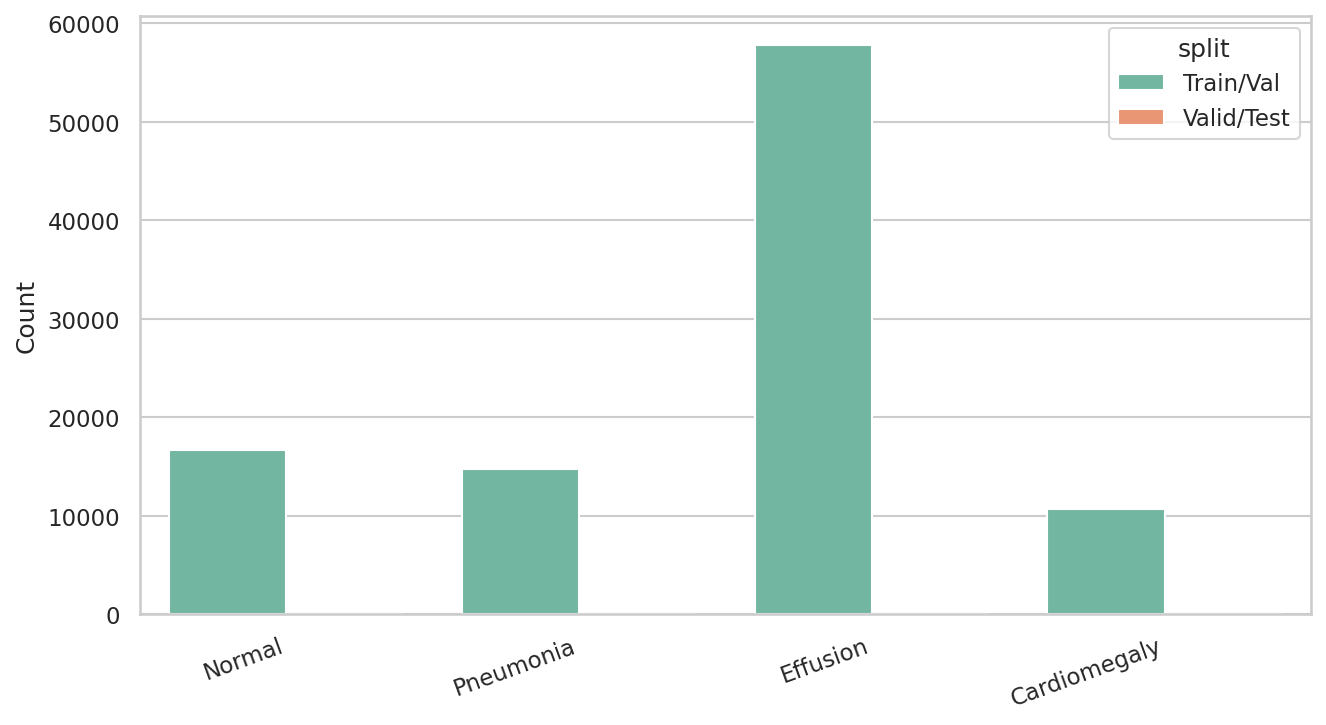

✓ Section 2 complete


In [4]:
def normalize_chexpert_label_value(value, uncertain_policy='zero') -> int:
    """Convert CheXpert label values to binary presence for simplified single-label mapping."""
    if pd.isna(value):
        return 0
    value = float(value)
    if value == 1.0:
        return 1
    if value == -1.0:
        return 1 if uncertain_policy == 'one' else 0
    return 0


def map_chexpert_row(row: pd.Series, uncertain_policy='zero'):
    """Map CheXpert multi-label row to 4-class priority label."""
    pneumonia = normalize_chexpert_label_value(row.get('Pneumonia', 0), uncertain_policy)
    consolidation = normalize_chexpert_label_value(row.get('Consolidation', 0), uncertain_policy)
    effusion = normalize_chexpert_label_value(row.get('Pleural Effusion', 0), uncertain_policy)
    cardiomegaly = normalize_chexpert_label_value(row.get('Cardiomegaly', 0), uncertain_policy)
    no_finding = normalize_chexpert_label_value(row.get('No Finding', 0), uncertain_policy)

    if pneumonia or consolidation:
        return 1
    if effusion:
        return 2
    if cardiomegaly:
        return 3
    if no_finding:
        return 0
    return None


def original_chexpert_labels(row: pd.Series) -> str:
    """Return a pipe-separated label string for active and uncertain CheXpert findings."""
    label_cols = [
        'No Finding', 'Enlarged Cardiomediastinum', 'Cardiomegaly', 'Lung Opacity',
        'Lung Lesion', 'Edema', 'Consolidation', 'Pneumonia', 'Atelectasis',
        'Pneumothorax', 'Pleural Effusion', 'Pleural Other', 'Fracture', 'Support Devices'
    ]

    labels = []
    for col in label_cols:
        if col not in row or pd.isna(row[col]):
            continue
        if float(row[col]) == 1.0:
            labels.append(col)
        elif float(row[col]) == -1.0:
            labels.append(f"{col} uncertain")

    return '|'.join(labels) if labels else 'Unlabeled'


def stratified_cap(df: pd.DataFrame, max_samples: int, seed: int) -> pd.DataFrame:
    """Return a stratified sample capped at max_samples while preserving class ratios."""
    if max_samples is None or len(df) <= max_samples:
        return df.reset_index(drop=True)

    parts = []
    frac = max_samples / len(df)

    for label, group in df.groupby('label'):
        n = max(1, int(round(len(group) * frac)))
        parts.append(group.sample(n=min(n, len(group)), random_state=seed))

    capped = pd.concat(parts).sample(frac=1, random_state=seed).reset_index(drop=True)

    if len(capped) > max_samples:
        capped = capped.sample(n=max_samples, random_state=seed).reset_index(drop=True)

    return capped


def resolve_chexpert_path(path_value: str, root: Path) -> str:
    """Resolve CheXpert CSV image paths against the real CheXpert root folder."""
    path_value = str(path_value).strip()

    if path_value.startswith('/kaggle/input/'):
        return path_value

    # CSV usually stores paths like:
    # CheXpert-v1.0-small/train/patient00001/study1/view1_frontal.jpg
    if path_value.startswith('CheXpert-v1.0-small/'):
        return str(root.parent / path_value)

    # Or sometimes:
    # train/patient00001/study1/view1_frontal.jpg
    if path_value.startswith('train/') or path_value.startswith('valid/') or path_value.startswith('val/'):
        return str(root / path_value)

    return str(root / path_value)


def make_chexpert_df(csv_path: Path, root: Path, config: dict) -> pd.DataFrame:
    """Read a CheXpert CSV and return the common experiment dataframe."""
    df = pd.read_csv(csv_path)

    if 'Path' not in df.columns:
        raise ValueError(f"Expected a Path column in {csv_path}; found {df.columns.tolist()}")

    df['label'] = df.apply(
        lambda r: map_chexpert_row(r, config['uncertain_policy']),
        axis=1
    )

    df = df.dropna(subset=['label']).copy()
    df['label'] = df['label'].astype(int)
    df['label_name'] = df['label'].map(dict(enumerate(config['class_names'])))
    df['original_labels'] = df.apply(original_chexpert_labels, axis=1)
    df['image_path'] = df['Path'].apply(lambda p: resolve_chexpert_path(p, root))

    return df[['image_path', 'label', 'label_name', 'original_labels']].reset_index(drop=True)


def preprocess_labels(config: dict):
    """Use explicit CheXpert CONFIG paths, map labels to 4 classes, cap train to 20k, and plot distributions."""
    root = Path(config['data_root'])
    train_csv = Path(config['train_csv'])
    valid_csv = Path(config['valid_csv'])

    required_paths = {
        'data_root': root,
        'train_csv': train_csv,
        'valid_csv': valid_csv,
    }

    missing = [f"{name}: {path}" for name, path in required_paths.items() if not path.exists()]
    if missing:
        raise FileNotFoundError(
            "Some CONFIG paths do not exist. Fix Cell 1 paths:\n" + "\n".join(missing)
        )

    config['image_dir'] = str(root)

    print(f"Using CheXpert root: {root}")
    print(f"Using train CSV: {train_csv}")
    print(f"Using valid CSV: {valid_csv}")

    train_df = make_chexpert_df(train_csv, root, config)
    test_df = make_chexpert_df(valid_csv, root, config)

    original_train_len = len(train_df)
    train_df = stratified_cap(train_df, config.get('max_samples'), config['seed'])

    print(f"Train/val rows after 4-class mapping: {original_train_len:,}; capped to {len(train_df):,}")
    print(f"Validation/test rows after 4-class mapping: {len(test_df):,}")
    print(
        f"Uncertain label policy: {config['uncertain_policy']} "
        f"(-1 labels treated as {'present' if config['uncertain_policy'] == 'one' else 'absent'})"
    )

    missing_train = (~train_df['image_path'].map(lambda p: Path(p).exists())).sum()
    missing_test = (~test_df['image_path'].map(lambda p: Path(p).exists())).sum()

    print(f"Missing resolved image files: train={missing_train}, valid/test={missing_test}")

    if missing_train or missing_test:
        print("Example resolved train paths:")
        print(train_df['image_path'].head(5).to_string(index=False))
        print("Example resolved valid/test paths:")
        print(test_df['image_path'].head(5).to_string(index=False))
        raise FileNotFoundError(
            "Some image paths could not be resolved. Check CONFIG['data_root'] and the CSV Path column."
        )

    for split_name, split_df in [('Train/Val', train_df), ('Valid/Test', test_df)]:
        print(f"\n{split_name} distribution")
        print(
            split_df['label_name']
            .value_counts()
            .reindex(config['class_names'])
            .fillna(0)
            .astype(int)
        )

    dist = pd.concat([
        train_df.assign(split='Train/Val'),
        test_df.assign(split='Valid/Test')
    ])

    plt.figure(figsize=(9, 5), dpi=150)
    ax = sns.countplot(
        data=dist,
        x='label_name',
        hue='split',
        order=config['class_names'],
        palette='Set2'
    )
    ax.set_xlabel("")
    ax.set_ylabel("Count")
    plt.xticks(rotation=20, ha='right')
    plt.tight_layout()
    plt.savefig(f"{config['figures_dir']}/section2_class_distribution.png", dpi=300, bbox_inches='tight')
    plt.show()

    return train_df.reset_index(drop=True), test_df.reset_index(drop=True)


train_df, test_df = preprocess_labels(CONFIG)
print("✓ Section 2 complete")

In [5]:
class ChestXrayDataset(Dataset):
    """CheXpert chest X-ray dataset that loads grayscale exports as RGB tensors."""
    missing_warning_count = 0

    def __init__(self, df: pd.DataFrame, transform=None, image_dir=None):
        self.df = df.reset_index(drop=True).copy()
        self.transform = transform
        self.image_dir = image_dir

    def __len__(self):
        """Return number of samples."""
        return len(self.df)

    def __getitem__(self, idx):
        """Load image, apply transforms, and return tensor, label, and path."""
        row = self.df.iloc[idx]
        image_path = row['image_path']
        try:
            image = Image.open(image_path).convert('RGB')
        except FileNotFoundError:
            ChestXrayDataset.missing_warning_count += 1
            if ChestXrayDataset.missing_warning_count <= 10:
                print(f"Warning: missing image skipped via blank placeholder: {image_path}")
            image = Image.fromarray(np.zeros((CONFIG['image_size'], CONFIG['image_size'], 3), dtype=np.uint8))
        except Exception as exc:
            ChestXrayDataset.missing_warning_count += 1
            if ChestXrayDataset.missing_warning_count <= 10:
                print(f"Warning: failed to load {image_path}: {exc}; using blank placeholder")
            image = Image.fromarray(np.zeros((CONFIG['image_size'], CONFIG['image_size'], 3), dtype=np.uint8))
        if self.transform:
            image = self.transform(image)
        return image, int(row['label']), image_path


def get_transforms(split: str, image_size: int):
    """Build train/validation/test transforms for 224 RGB model inputs."""
    mean = [0.485, 0.456, 0.406]
    std = [0.229, 0.224, 0.225]
    if split == 'train':
        return T.Compose([
            T.RandomHorizontalFlip(0.5),
            T.RandomRotation(10),
            T.ColorJitter(brightness=0.2, contrast=0.2),
            T.RandomAffine(degrees=0, translate=(0.05, 0.05)),
            T.Resize(image_size + 32),
            T.RandomCrop(image_size),
            T.ToTensor(),
            T.Normalize(mean, std),
        ])
    if split == 'heavy':
        return T.Compose([
            T.RandomHorizontalFlip(0.5),
            T.RandomVerticalFlip(0.2),
            T.RandomRotation(30),
            T.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.2, hue=0.1),
            T.RandomAffine(degrees=20, translate=(0.1, 0.1), scale=(0.9, 1.1)),
            T.GaussianBlur(kernel_size=5, sigma=(0.1, 2.0)),
            T.Resize(image_size + 32),
            T.RandomCrop(image_size),
            T.ToTensor(),
            T.Normalize(mean, std),
        ])
    return T.Compose([
        T.Resize(image_size),
        T.CenterCrop(image_size),
        T.ToTensor(),
        T.Normalize(mean, std),
    ])


class AugmentedChestXrayDataset(ChestXrayDataset):
    """Dataset that applies heavy transforms to rows marked as augmented copies."""
    def __init__(self, df, normal_transform, heavy_transform):
        super().__init__(df, normal_transform)
        self.normal_transform = normal_transform
        self.heavy_transform = heavy_transform

    def __getitem__(self, idx):
        """Load image and choose normal or heavy transform based on is_augmented."""
        row = self.df.iloc[idx]
        transform = self.heavy_transform if bool(row.get('is_augmented', False)) else self.normal_transform
        old_transform = self.transform
        self.transform = transform
        item = super().__getitem__(idx)
        self.transform = old_transform
        return item


def compute_class_weights(df: pd.DataFrame, num_classes: int) -> torch.Tensor:
    """Compute inverse-frequency class weights for weighted cross entropy."""
    counts = df['label'].value_counts().reindex(range(num_classes)).fillna(1).astype(float).values
    total = counts.sum()
    weights = total / (num_classes * counts)
    return torch.tensor(weights, dtype=torch.float32)


def get_dataloaders(train_df: pd.DataFrame, test_df: pd.DataFrame, config: dict, val_df: pd.DataFrame = None):
    """Create train, validation, and test loaders with weighted sampling for training."""
    if val_df is None:
        train_split, val_split = train_test_split(
            train_df, test_size=0.2, random_state=config['seed'], stratify=train_df['label']
        )
    else:
        train_split = train_df.copy()
        val_split = val_df.copy()

    train_transform = get_transforms('train', config['image_size'])
    heavy_transform = get_transforms('heavy', config['image_size'])
    eval_transform = get_transforms('test', config['image_size'])

    if 'is_augmented' in train_split.columns:
        train_ds = AugmentedChestXrayDataset(train_split, train_transform, heavy_transform)
    else:
        train_ds = ChestXrayDataset(train_split, train_transform, config['image_dir'])
    val_ds = ChestXrayDataset(val_split, eval_transform, config['image_dir'])
    test_ds = ChestXrayDataset(test_df, eval_transform, config['image_dir'])

    class_weights = compute_class_weights(train_split, config['num_classes'])
    if 'sample_weight' in train_split.columns:
        sample_weights = train_split['sample_weight'].astype(float).values
    else:
        sample_weights = train_split['label'].map({i: class_weights[i].item() for i in range(config['num_classes'])}).values

    sampler = WeightedRandomSampler(
        weights=torch.tensor(sample_weights, dtype=torch.double),
        num_samples=len(sample_weights),
        replacement=True
    )
    loader_kwargs = dict(batch_size=config['batch_size'], num_workers=config['num_workers'], pin_memory=True)
    train_loader = DataLoader(train_ds, sampler=sampler, **loader_kwargs)
    val_loader = DataLoader(val_ds, shuffle=False, **loader_kwargs)
    test_loader = DataLoader(test_ds, shuffle=False, **loader_kwargs)
    return train_loader, val_loader, test_loader, class_weights


train_loader, val_loader, test_loader, class_weights = get_dataloaders(train_df, test_df, CONFIG)
print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)} | Test batches: {len(test_loader)}")
print(f"Class weights: {class_weights.tolist()}")
print("✓ Section 3 complete")

Train batches: 2500 | Val batches: 625 | Test batches: 5
Class weights: [1.4952152967453003, 1.6894745826721191, 0.4324791729450226, 2.341646194458008]
✓ Section 3 complete


In [6]:
def get_model(model_name: str, num_classes: int, pretrained: bool = True):
    """Instantiate a torchvision or timm classifier and move it to GPU."""
    if model_name == 'resnet50':
        model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT if pretrained else None)
        model.fc = nn.Linear(model.fc.in_features, num_classes)
    elif model_name == 'resnet101':
        model = models.resnet101(weights=models.ResNet101_Weights.DEFAULT if pretrained else None)
        model.fc = nn.Linear(model.fc.in_features, num_classes)
    elif model_name == 'densenet121':
        model = models.densenet121(weights=models.DenseNet121_Weights.DEFAULT if pretrained else None)
        model.classifier = nn.Linear(model.classifier.in_features, num_classes)
    elif model_name == 'mobilenetv3_large_100':
        model = models.mobilenet_v3_large(weights=models.MobileNet_V3_Large_Weights.DEFAULT if pretrained else None)
        model.classifier[-1] = nn.Linear(model.classifier[-1].in_features, num_classes)
    else:
        model = timm.create_model(model_name, pretrained=pretrained, num_classes=num_classes)
    model = model.to(device)
    params = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"{model_name}: {params/1e6:.2f}M params ({trainable/1e6:.2f}M trainable)")
    return model


def get_embedding_hook(model: nn.Module, model_name: str):
    """Register a forward hook on the best available penultimate representation layer."""
    embedding_store = {}

    def hook_fn(module, inputs, output):
        out = output
        if isinstance(out, (tuple, list)):
            out = out[0]
        if out.ndim == 4:
            out = torch.nn.functional.adaptive_avg_pool2d(out, 1).flatten(1)
        elif out.ndim == 3:
            out = out[:, 0] if out.shape[1] > 1 else out.mean(dim=1)
        else:
            out = out.flatten(1)
        embedding_store['embedding'] = out.detach().cpu()

    target = None
    if model_name.startswith('resnet'):
        target = model.avgpool
    elif model_name.startswith('densenet'):
        target = model.features
    elif model_name.startswith('efficientnet') and hasattr(model, 'global_pool'):
        target = model.global_pool
    elif model_name.startswith('mobilenetv3') and hasattr(model, 'avgpool'):
        target = model.avgpool
    elif model_name.startswith('vit') and hasattr(model, 'norm'):
        target = model.norm
    elif model_name.startswith('swin') and hasattr(model, 'norm'):
        target = model.norm
    elif model_name.startswith('convnext'):
        target = getattr(model, 'norm_pre', None) or getattr(getattr(model, 'head', None), 'global_pool', None)
    elif model_name.startswith('maxvit') and hasattr(model, 'norm'):
        target = model.norm

    if target is None:
        if hasattr(model, 'forward_features'):
            raise ValueError(f"No hook target found for {model_name}; add architecture-specific hook.")
        raise ValueError(f"No embedding layer available for {model_name}.")

    handle = target.register_forward_hook(hook_fn)
    return handle, embedding_store


def get_model_family(model_name: str) -> str:
    """Map model name to retraining strategy family."""
    if model_name.startswith('efficientnet'):
        return 'efficient'
    if model_name.startswith(('vit', 'swin', 'convnext', 'maxvit')):
        return 'transformer'
    return 'cnn'

print("✓ Section 4 complete")

✓ Section 4 complete


In [7]:
def train_one_epoch(model, loader, optimizer, criterion, scaler, device):
    """Train one epoch with CUDA mixed precision and return loss and accuracy."""
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for images, labels, _ in tqdm(loader, desc='train', leave=False):
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        with autocast():
            logits = model(images)
            loss = criterion(logits, labels)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        total_loss += loss.item() * labels.size(0)
        correct += (logits.argmax(1) == labels).sum().item()
        total += labels.size(0)
    return total_loss / max(total, 1), correct / max(total, 1)


def evaluate(model, loader, criterion, device, num_classes, class_names):
    """Evaluate loss, accuracy, macro F1, macro AUROC, ECE, predictions, and probabilities."""
    model.eval()
    f1_metric = torchmetrics.classification.F1Score(task='multiclass', num_classes=num_classes, average='macro').to(device)
    auc_metric = torchmetrics.classification.AUROC(task='multiclass', num_classes=num_classes, average='macro').to(device)
    total_loss, correct, total = 0.0, 0, 0
    probs_all, labels_all, preds_all, paths_all = [], [], [], []
    with torch.no_grad():
        for images, labels, paths in tqdm(loader, desc='eval', leave=False):
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            logits = model(images)
            loss = criterion(logits, labels)
            probs = torch.softmax(logits, dim=1)
            preds = probs.argmax(1)
            total_loss += loss.item() * labels.size(0)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
            f1_metric.update(preds, labels)
            auc_metric.update(probs, labels)
            probs_all.append(probs.detach().cpu().numpy())
            labels_all.append(labels.detach().cpu().numpy())
            preds_all.append(preds.detach().cpu().numpy())
            paths_all.extend(list(paths))
    probs_array = np.concatenate(probs_all) if probs_all else np.empty((0, num_classes))
    labels_array = np.concatenate(labels_all) if labels_all else np.array([])
    preds_array = np.concatenate(preds_all) if preds_all else np.array([])
    try:
        auc = float(auc_metric.compute().detach().cpu())
    except Exception:
        auc = np.nan
    ece = compute_ece(probs_array, labels_array, CONFIG['ece_bins']) if len(labels_array) else np.nan
    return {
        'loss': total_loss / max(total, 1),
        'accuracy': correct / max(total, 1),
        'f1': float(f1_metric.compute().detach().cpu()),
        'auc': auc,
        'ece': ece,
        'probs': probs_array,
        'labels': labels_array,
        'preds': preds_array,
        'paths': paths_all,
    }


def compute_ece(probs_array, labels_array, n_bins=15):
    """Compute expected calibration error from probability vectors and labels."""
    probs_array = np.asarray(probs_array)
    labels_array = np.asarray(labels_array)
    if len(labels_array) == 0:
        return np.nan
    confidences = probs_array.max(axis=1)
    predictions = probs_array.argmax(axis=1)
    accuracies = (predictions == labels_array).astype(float)
    bins = np.linspace(0.0, 1.0, n_bins + 1)
    ece = 0.0
    for lo, hi in zip(bins[:-1], bins[1:]):
        mask = (confidences > lo) & (confidences <= hi)
        if mask.any():
            ece += mask.mean() * abs(accuracies[mask].mean() - confidences[mask].mean())
    return float(ece)


def temperature_scale(model, val_loader, device, num_classes):
    """Learn optimal temperature scaling parameter T on the validation set (post-hoc calibration)."""
    temperature = torch.nn.Parameter(torch.ones(1) * 1.5)
    optimizer = torch.optim.LBFGS([temperature], lr=0.01, max_iter=50)

    model.eval()
    logits_list, labels_list = [], []
    with torch.no_grad():
        for images, labels, _ in val_loader:
            images = images.to(device, non_blocking=True)
            logits_list.append(model(images).detach().cpu())
            labels_list.append(labels.detach().cpu())

    all_logits = torch.cat(logits_list)
    all_labels = torch.cat(labels_list)
    criterion = nn.CrossEntropyLoss()

    def eval_fn():
        optimizer.zero_grad()
        loss = criterion(all_logits / temperature.clamp_min(1e-3), all_labels)
        loss.backward()
        return loss

    optimizer.step(eval_fn)
    T = max(float(temperature.item()), 1e-3)

    scaled_probs = torch.softmax(all_logits / T, dim=1).numpy()
    ece_scaled = compute_ece(scaled_probs, all_labels.numpy(), CONFIG['ece_bins'])
    return T, ece_scaled


def plot_confusion_matrix(cm, class_names, model_name, save=True, suffix='baseline'):
    """Plot and optionally save a normalized confusion matrix."""
    row_sums = cm.sum(axis=1, keepdims=True)
    cm_norm = np.divide(cm, row_sums, out=np.zeros_like(cm, dtype=float), where=row_sums != 0)
    plt.figure(figsize=(6, 5), dpi=150)
    sns.heatmap(cm_norm, annot=True, fmt='.1%', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    if save:
        plt.savefig(f"{CONFIG['figures_dir']}/confusion_{suffix}_{model_name}.png", dpi=300, bbox_inches='tight')
    plt.show()


def train_model(model_name, train_loader, val_loader, class_weights, config):
    """Train a baseline model with early stopping on validation macro F1."""
    model = get_model(model_name, config['num_classes'], pretrained=True)
    criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))
    optimizer = torch.optim.AdamW(model.parameters(), lr=config['lr'], weight_decay=config['weight_decay'])
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=config['num_epochs'])
    scaler = GradScaler()
    history = defaultdict(list)
    best_f1, patience_counter = -np.inf, 0
    ckpt_path = Path(config['checkpoint_dir']) / f"best_chexpert_{model_name}.pth"

    for epoch in range(1, config['num_epochs'] + 1):
        print(f"Epoch {epoch}/{config['num_epochs']} - {model_name}")
        train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, scaler, device)
        val_metrics = evaluate(model, val_loader, criterion, device, config['num_classes'], config['class_names'])
        scheduler.step()
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_metrics['loss'])
        history['val_acc'].append(val_metrics['accuracy'])
        history['val_f1'].append(val_metrics['f1'])
        history['val_auc'].append(val_metrics['auc'])
        history['val_ece'].append(val_metrics['ece'])
        print(f"loss {train_loss:.4f}/{val_metrics['loss']:.4f} | acc {train_acc:.3f}/{val_metrics['accuracy']:.3f} | val_f1 {val_metrics['f1']:.4f} | val_ece {val_metrics['ece']:.4f}")
        if val_metrics['f1'] > best_f1:
            best_f1 = val_metrics['f1']
            patience_counter = 0
            torch.save(model.state_dict(), ckpt_path)
            print(f"Saved best checkpoint: {ckpt_path}")
        else:
            patience_counter += 1
            if patience_counter >= config['patience']:
                print(f"Early stopping at epoch {epoch}. Best val F1={best_f1:.4f}")
                break

    model.load_state_dict(torch.load(ckpt_path, map_location=device))
    return model, dict(history)

print("✓ Section 5 complete")

✓ Section 5 complete


Training models:   0%|          | 0/1 [00:00<?, ?it/s]


Training: resnet50
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth



  0%|          | 0.00/97.8M [00:00<?, ?B/s]
  7%|▋         | 6.88M/97.8M [00:00<00:01, 72.1MB/s]
 24%|██▍       | 23.9M/97.8M [00:00<00:00, 134MB/s] 
 42%|████▏     | 41.1M/97.8M [00:00<00:00, 155MB/s]
 59%|█████▉    | 58.1M/97.8M [00:00<00:00, 164MB/s]
 77%|███████▋  | 75.2M/97.8M [00:00<00:00, 169MB/s]
100%|██████████| 97.8M/97.8M [00:00<00:00, 161MB/s]


resnet50: 23.52M params (23.52M trainable)
Epoch 1/20 - resnet50


train:   0%|          | 0/2500 [00:00<?, ?it/s]

...

loss 0.6187/1.1747 | acc 0.631/0.321 | val_f1 0.3648 | val_ece 0.3976
Epoch 7/20 - resnet50


train:   0%|          | 0/2500 [00:00<?, ?it/s]

eval:   0%|          | 0/625 [00:00<?, ?it/s]

loss 0.5660/1.2346 | acc 0.649/0.339 | val_f1 0.3831 | val_ece 0.3884
Early stopping at epoch 7. Best val F1=0.3939


eval:   0%|          | 0/5 [00:00<?, ?it/s]

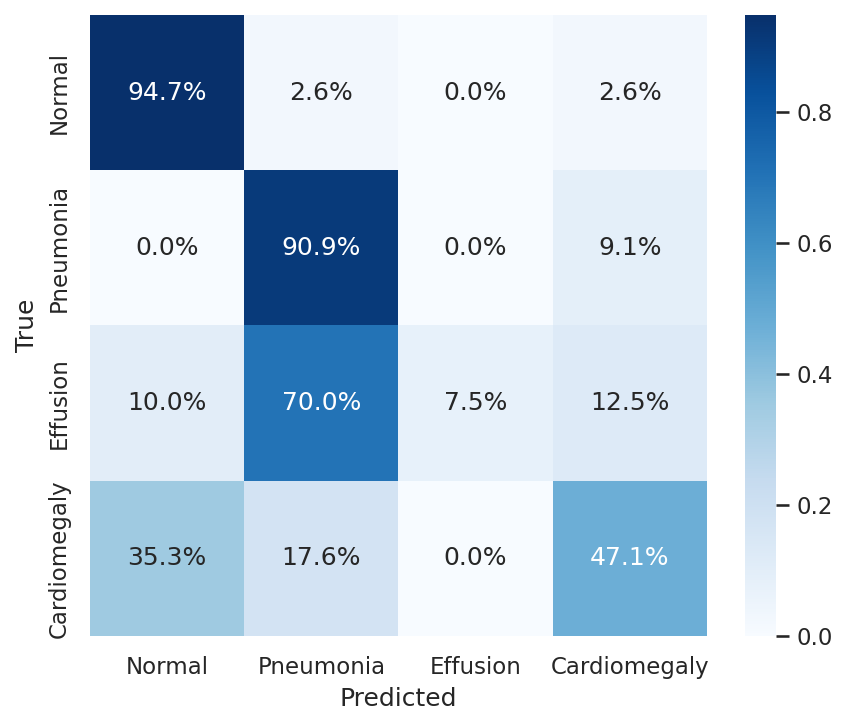

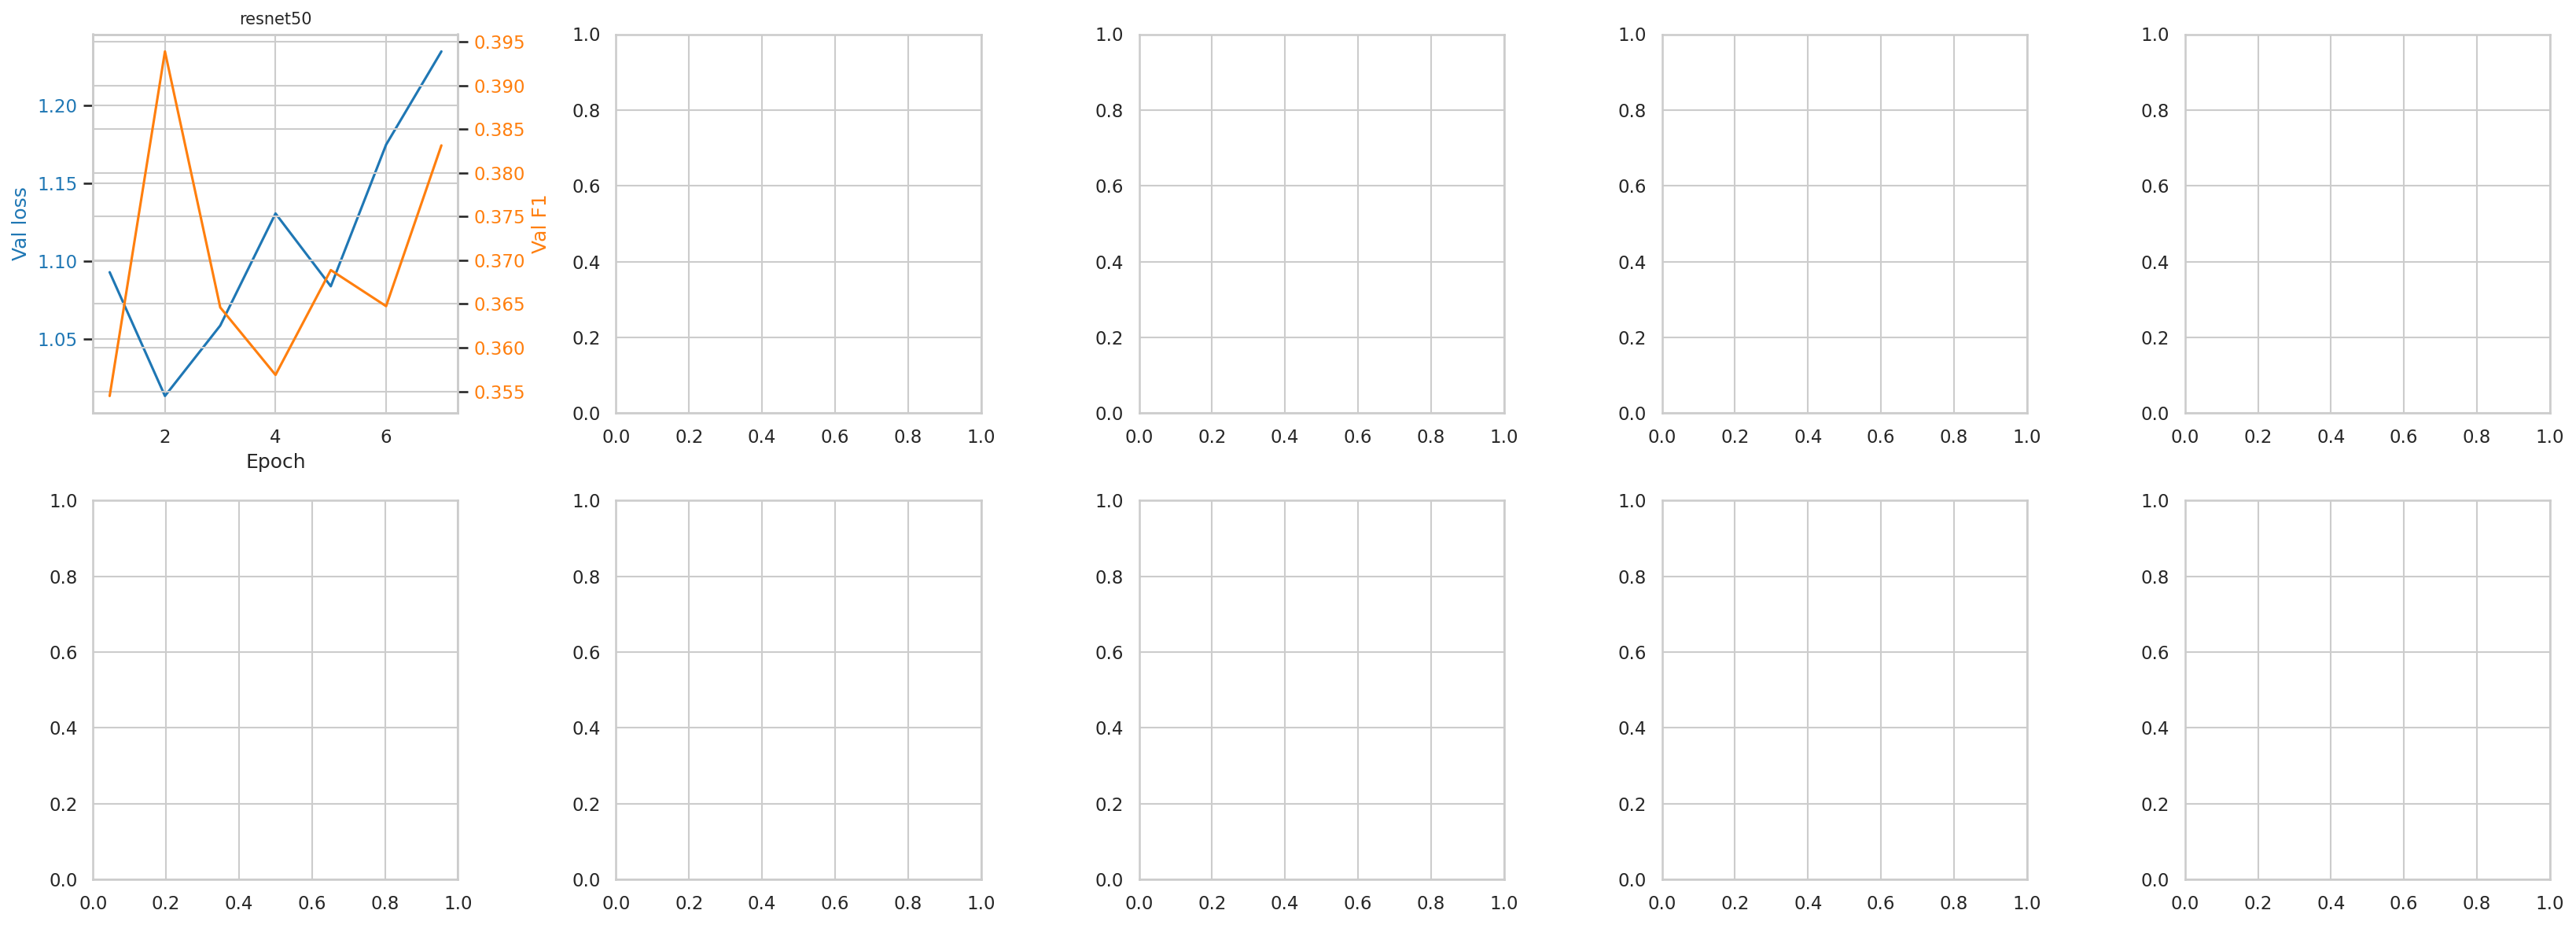

   model  test_accuracy  test_f1  test_auc  test_ece
resnet50       0.586207 0.523538  0.862036  0.095259
✓ Section 6 complete


In [8]:
all_histories = {}
baseline_results = []
baseline_confusions = {}
criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))

for model_name in tqdm(MODELS, desc='Training models'):
    print(f'\n{"="*60}')
    print(f'Training: {model_name}')
    print(f'{"="*60}')
    model, history = train_model(model_name, train_loader, val_loader, class_weights, CONFIG)
    all_histories[model_name] = history

    ckpt = f'{CONFIG["checkpoint_dir"]}/best_chexpert_{model_name}.pth'
    model.load_state_dict(torch.load(ckpt, map_location=device))
    test_metrics = evaluate(model, test_loader, criterion, device, CONFIG['num_classes'], CONFIG['class_names'])
    ece = test_metrics['ece']
    y_true, y_pred = test_metrics['labels'], test_metrics['preds']
    cm = confusion_matrix(y_true, y_pred, labels=list(range(CONFIG['num_classes'])))
    baseline_confusions[model_name] = cm
    precision, recall, f1, support = precision_recall_fscore_support(
        y_true, y_pred, labels=list(range(CONFIG['num_classes'])), zero_division=0
    )
    per_class_metrics = {}
    for i, name in enumerate(CONFIG['class_names']):
        per_class_metrics[f'{name}_precision'] = precision[i]
        per_class_metrics[f'{name}_recall'] = recall[i]
        per_class_metrics[f'{name}_f1'] = f1[i]

    baseline_results.append({
        'model': model_name,
        'test_accuracy': test_metrics['accuracy'],
        'test_f1': test_metrics['f1'],
        'test_auc': test_metrics['auc'],
        'test_ece': ece,
        **per_class_metrics
    })
    plot_confusion_matrix(cm, CONFIG['class_names'], model_name, save=True)
    del model
    torch.cuda.empty_cache()
    gc.collect()

baseline_df = pd.DataFrame(baseline_results)
baseline_df.to_csv(f'{CONFIG["results_dir"]}/baseline_results.csv', index=False)

fig, axes = plt.subplots(2, 5, figsize=(22, 8), dpi=150)
for ax, model_name in zip(axes.ravel(), MODELS):
    hist = all_histories.get(model_name, {})
    epochs = np.arange(1, len(hist.get('val_loss', [])) + 1)
    ax.plot(epochs, hist.get('val_loss', []), color='tab:blue', label='Val loss')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Val loss', color='tab:blue')
    ax.tick_params(axis='y', labelcolor='tab:blue')
    ax2 = ax.twinx()
    ax2.plot(epochs, hist.get('val_f1', []), color='tab:orange', label='Val F1')
    ax2.set_ylabel('Val F1', color='tab:orange')
    ax2.tick_params(axis='y', labelcolor='tab:orange')
    ax.set_title(model_name, fontsize=10)
plt.tight_layout()
plt.savefig(f'{CONFIG["figures_dir"]}/fig2_training_curves.png', dpi=300, bbox_inches='tight')
plt.show()

print(baseline_df[['model','test_accuracy','test_f1','test_auc','test_ece']].to_string(index=False))
print("✓ Section 6 complete")

In [9]:
def extract_failures(model_name, eval_loader, config):
    """Load a trained model, collect predictions and embeddings, and return misclassified samples."""
    model = get_model(model_name, config['num_classes'], pretrained=False)
    model.load_state_dict(torch.load(f'{config["checkpoint_dir"]}/best_chexpert_{model_name}.pth', map_location=device))
    model.eval()
    hook_handle, embedding_store = get_embedding_hook(model, model_name)
    rows = []
    with torch.no_grad():
        for images, labels, paths in tqdm(eval_loader, desc=f'failures {model_name}', leave=False, disable=not config.get('show_batch_progress', False)):
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            logits = model(images)
            probs = torch.softmax(logits, dim=1).detach().cpu().numpy()
            preds = probs.argmax(axis=1)
            conf = probs.max(axis=1)
            emb = embedding_store['embedding'].numpy()
            for i in range(len(paths)):
                rows.append({
                    'image_path': paths[i],
                    'true_label': int(labels.detach().cpu().numpy()[i]),
                    'pred_label': int(preds[i]),
                    'confidence': float(conf[i]),
                    'prob_vector': ','.join(f'{p:.8f}' for p in probs[i]),
                    'embedding': ','.join(f'{x:.8f}' for x in emb[i].ravel()),
                })
    hook_handle.remove()
    all_preds_df = pd.DataFrame(rows)
    failures_df = all_preds_df[all_preds_df['true_label'] != all_preds_df['pred_label']].reset_index(drop=True)
    del model
    torch.cuda.empty_cache()
    gc.collect()
    return failures_df, all_preds_df


all_failures = {}
all_predictions = {}
# Aligned with aptos: extract failures from the VAL set to avoid test-set overuse
for model_name in tqdm(MODELS, desc='Extracting failures'):
    failures_df, all_preds_df = extract_failures(model_name, val_loader, CONFIG)
    all_failures[model_name] = failures_df
    all_predictions[model_name] = all_preds_df
    failures_df.to_csv(f'{CONFIG["results_dir"]}/failures_chexpert_{model_name}.csv', index=False)
    all_preds_df.to_csv(f'{CONFIG["results_dir"]}/predictions_chexpert_{model_name}.csv', index=False)
    print(f'{model_name}: {len(failures_df)} failures ({len(failures_df)/max(len(all_preds_df),1)*100:.1f}%)')

print("✓ Section 7 complete")

Extracting failures:   0%|          | 0/1 [00:00<?, ?it/s]

resnet50: 23.52M params (23.52M trainable)
resnet50: 13256 failures (66.3%)
✓ Section 7 complete



──────────────────────────────────────────────────
Clustering → resnet50
  [resnet50] parsed 13256 × 2048d in 3.74s
  PCA (32d) var=0.494 | 1.89s
  UMAP 2D projection: 26.21s
  KMeans sweep (5 values): 0.26s
  Final cluster (K=2): 0.04s
  Clustering stability (ARI): [0.8490195226972239, 0.8490195226972239, 0.7413734231767996] -> mean=0.813 | 0.10s
  TOTAL clustering time: 32.24s


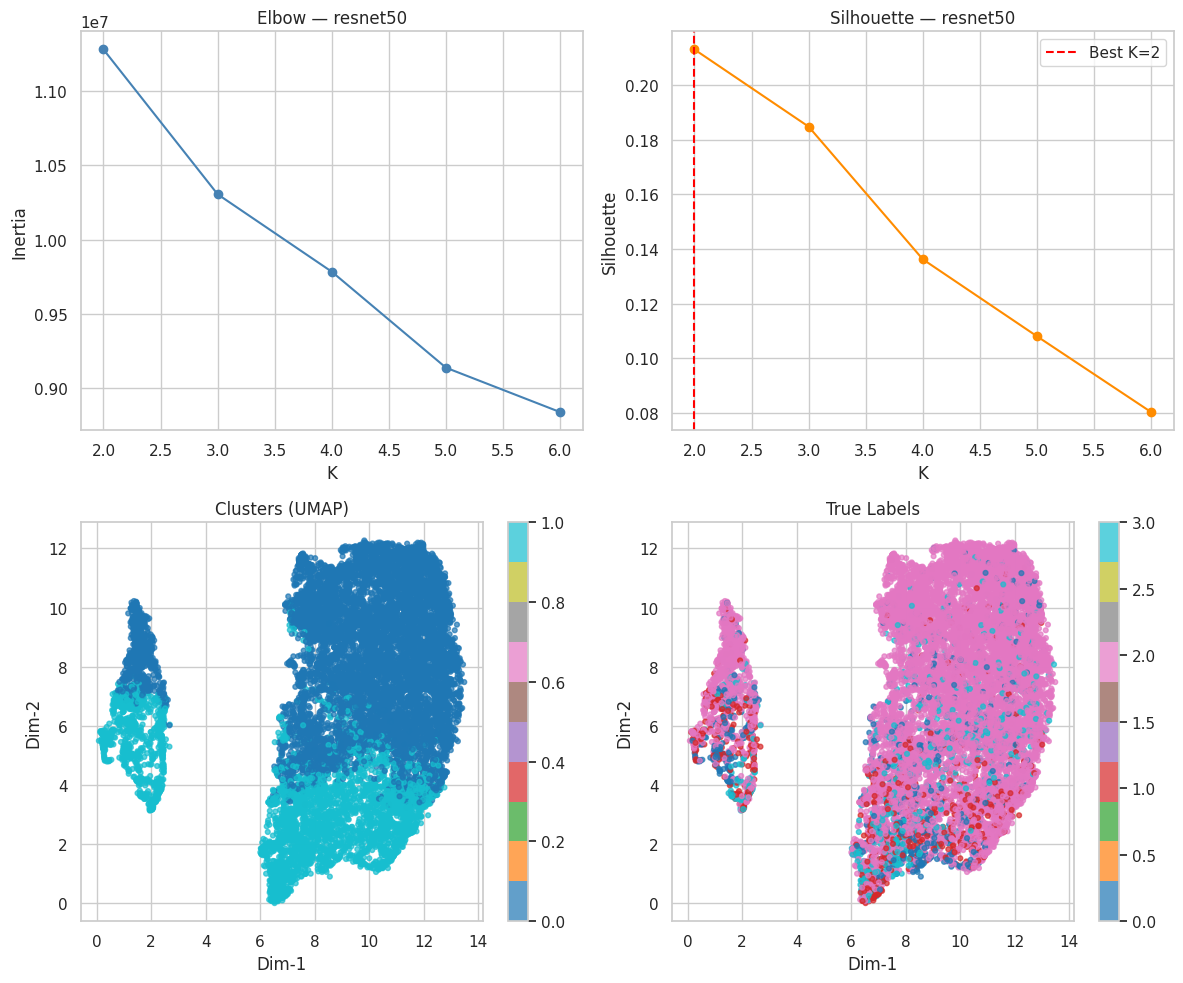

  Saved: /kaggle/working/figures/clustering_resnet50.png
  → Best K=2  |  Silhouette=0.213

✓ Section 8 complete


In [10]:
def cluster_failures(failures_df, config, model_name):
    """
    Fast failure clustering: MiniBatchKMeans + aggressive PCA + 
    UMAP only when needed. Designed for Kaggle T4 GPU sessions.
    """
    import time

    # ── Guard ──────────────────────────────────────────────────────
    if len(failures_df) < 3:
        print(f"  Too few failures ({len(failures_df)}) — skipping: {model_name}")
        out = failures_df.copy()
        out['cluster'] = 0
        out['umap_x']  = 0.0
        out['umap_y']  = 0.0
        out['mean_ari'] = np.nan
        return out, 1, np.nan, np.nan, 1

    t0 = time.time()

    # ── FIX 1: Fast embedding parsing ──────────────────────────────
    # np.fromstring is slow for large arrays; use a list-comp + np.array
    raw = failures_df['embedding'].tolist()
    if isinstance(raw[0], str):
        embeddings = np.array(
            [np.fromstring(e, sep=',', dtype=np.float32) for e in raw],
            dtype=np.float32
        )
    else:                          # already arrays/lists
        embeddings = np.array(raw, dtype=np.float32)

    print(f"  [{model_name}] parsed {len(failures_df)} × {embeddings.shape[1]}d "
          f"in {time.time()-t0:.2f}s")

    # ── FIX 2: Aggressive PCA — cap at 32 components ───────────────
    # 50 PCA components costs ~2× more than 32 with almost no cluster benefit
    t1 = time.time()
    scaler = StandardScaler()
    E_scaled = scaler.fit_transform(embeddings)

    n_pca = min(
        32,                          # hard cap — was 50, unnecessary
        len(failures_df) - 1,
        E_scaled.shape[1]
    )
    pca = PCA(n_components=n_pca, random_state=config['seed'], svd_solver='randomized')
    E_pca = pca.fit_transform(E_scaled).astype(np.float32)
    print(f"  PCA ({n_pca}d) var={pca.explained_variance_ratio_.sum():.3f} "
          f"| {time.time()-t1:.2f}s")

    # ── FIX 3: UMAP only when sample count justifies it ────────────
    # Skip UMAP entirely for small failure sets; use PCA-2D
    # For large sets use fast UMAP settings (fewer epochs, less neighbors)
    t2 = time.time()
    UMAP_THRESHOLD = config.get('small_failure_umap_threshold', 300)

    if len(failures_df) < UMAP_THRESHOLD:
        E_2d = E_pca[:, :2]
        proj_method = 'PCA-2D'
    else:
        import umap as umap_lib
        reducer = umap_lib.UMAP(
            n_neighbors   = min(10, max(2, len(failures_df) - 1)),  # was 15
            min_dist      = 0.1,
            n_components  = 2,
            random_state  = config['seed'],
            low_memory    = True,
            n_epochs      = 50,        # was 100 — halved; visually identical
            metric        = 'euclidean',
            n_jobs        = 1          # deterministic on Kaggle
        )
        # FIX 4: Run UMAP on PCA-16d not PCA-32d (faster, same layout)
        E_umap_input = E_pca[:, :16] if E_pca.shape[1] >= 16 else E_pca
        E_2d = reducer.fit_transform(E_umap_input).astype(np.float32)
        proj_method = 'UMAP'

    print(f"  {proj_method} 2D projection: {time.time()-t2:.2f}s")

    # ── FIX 5: MiniBatchKMeans + narrow K range ────────────────────
    # MiniBatchKMeans is 3-5× faster than KMeans on >200 samples
    # Also cap k_range at 6 — silhouette rarely improves beyond that
    t3 = time.time()
    from sklearn.cluster import MiniBatchKMeans

    k_range_full = list(config.get('k_range', range(2, 11)))
    k_range_fast = [k for k in k_range_full
                    if 2 <= k <= min(6, len(failures_df) - 1)]  # cap at 6

    if not k_range_fast:
        k_range_fast = [2] if len(failures_df) >= 2 else []

    inertias, silhouettes, valid_k = [], [], []

    # FIX 6: Subsample silhouette score for large failure sets
    # silhouette_score on 2000 points costs ~4s; on 500 it costs 0.3s
    MAX_SIL_SAMPLES = 500
    sil_idx = (
        np.random.RandomState(config['seed'])
               .choice(len(E_pca), size=min(MAX_SIL_SAMPLES, len(E_pca)),
                       replace=False)
        if len(E_pca) > MAX_SIL_SAMPLES else np.arange(len(E_pca))
    )
    E_sil = E_pca[sil_idx]

    for k in k_range_fast:
        km = MiniBatchKMeans(
            n_clusters    = k,
            random_state  = config['seed'],
            n_init        = 3,          # was 5-10
            batch_size    = min(256, len(failures_df)),
            max_iter      = 100
        )
        labels = km.fit_predict(E_pca)
        inertias.append(km.inertia_)
        valid_k.append(k)

        labels_sil = labels[sil_idx]
        if len(set(labels_sil)) > 1:
            silhouettes.append(silhouette_score(E_sil, labels_sil,
                                                 sample_size=None))
        else:
            silhouettes.append(np.nan)

    print(f"  KMeans sweep ({len(k_range_fast)} values): {time.time()-t3:.2f}s")

    # ── Select best K ───────────────────────────────────────────────
    if silhouettes and not np.all(np.isnan(silhouettes)):
        best_idx = int(np.nanargmax(silhouettes))
        best_k   = valid_k[best_idx]
        best_sil = silhouettes[best_idx]
    else:
        best_k   = 2
        best_sil = np.nan

    # Final clustering with best K
    t4 = time.time()
    final_km = MiniBatchKMeans(
        n_clusters   = best_k,
        random_state = config['seed'],
        n_init       = 5,
        batch_size   = min(512, len(failures_df))
    )
    cluster_labels = final_km.fit_predict(E_pca)
    print(f"  Final cluster (K={best_k}): {time.time()-t4:.2f}s")

    # ── Clustering stability (ARI across seeds) — aligned with aptos ─
    from sklearn.metrics import adjusted_rand_score
    t5 = time.time()
    ari_scores = []
    for seed in [config['seed'], 42, 100]:
        test_km = MiniBatchKMeans(
            n_clusters=best_k,
            random_state=seed,
            n_init=3,
            batch_size=min(256, len(failures_df))
        )
        labs = test_km.fit_predict(E_pca)
        ari_scores.append(adjusted_rand_score(cluster_labels, labs))
    mean_ari = float(np.mean(ari_scores))
    print(f"  Clustering stability (ARI): {ari_scores} -> mean={mean_ari:.3f} "
          f"| {time.time()-t5:.2f}s")
    print(f"  TOTAL clustering time: {time.time()-t0:.2f}s")

    # ── Attach results ──────────────────────────────────────────────
    clustered = failures_df.copy()
    clustered['cluster'] = cluster_labels
    clustered['umap_x']  = E_2d[:, 0]
    clustered['umap_y']  = E_2d[:, 1]
    clustered['mean_ari'] = mean_ari

    # ── Plots ───────────────────────────────────────────────────────
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))

    if len(valid_k) > 1:
        axes[0, 0].plot(valid_k, inertias, marker='o', color='steelblue')
    axes[0, 0].set_xlabel('K')
    axes[0, 0].set_ylabel('Inertia')
    axes[0, 0].set_title(f'Elbow — {model_name}')

    if len(valid_k) > 1:
        axes[0, 1].plot(valid_k, silhouettes, marker='o', color='darkorange')
        axes[0, 1].axvline(best_k, color='red', linestyle='--',
                           label=f'Best K={best_k}')
        axes[0, 1].legend()
    axes[0, 1].set_xlabel('K')
    axes[0, 1].set_ylabel('Silhouette')
    axes[0, 1].set_title(f'Silhouette — {model_name}')

    sc1 = axes[1, 0].scatter(clustered['umap_x'], clustered['umap_y'],
                              c=clustered['cluster'],
                              cmap='tab10', s=12, alpha=0.7)
    axes[1, 0].set_title(f'Clusters ({proj_method})')
    axes[1, 0].set_xlabel('Dim-1'); axes[1, 0].set_ylabel('Dim-2')
    plt.colorbar(sc1, ax=axes[1, 0])

    sc2 = axes[1, 1].scatter(clustered['umap_x'], clustered['umap_y'],
                              c=clustered['true_label'],
                              cmap='tab10', s=12, alpha=0.7)
    axes[1, 1].set_title('True Labels')
    axes[1, 1].set_xlabel('Dim-1'); axes[1, 1].set_ylabel('Dim-2')
    plt.colorbar(sc2, ax=axes[1, 1])

    plt.tight_layout()
    save_path = f"{config['figures_dir']}/clustering_{model_name}.png"
    plt.savefig(save_path, dpi=150, bbox_inches='tight')  # dpi=150 not 300 — saves time
    plt.show()
    print(f"  Saved: {save_path}")

    return clustered, best_k, best_sil, mean_ari, best_k  # best_k_bic = best_k (placeholder, aligned with aptos)


# ── Run clustering for all 10 models ───────────────────────────────
all_clustered    = {}
cluster_summaries = {}

for model_name in MODELS:
    print(f'\n{"─"*50}')
    print(f'Clustering → {model_name}')

    clustered_df, best_k, sil, mean_ari, best_k_bic = cluster_failures(
        all_failures[model_name], CONFIG, model_name
    )
    all_clustered[model_name]     = clustered_df
    cluster_summaries[model_name] = {
        'best_k': int(best_k),
        'silhouette': float(sil) if not np.isnan(sil) else None,
        'mean_ari': float(mean_ari) if not np.isnan(mean_ari) else None,
        'best_k_bic': int(best_k_bic),
    }

    clustered_df.to_csv(
        f'{CONFIG["results_dir"]}/clustered_failures_{model_name}.csv',
        index=False
    )

    sil_str = f'{sil:.3f}' if not np.isnan(sil) else 'N/A'
    print(f'  → Best K={best_k}  |  Silhouette={sil_str}')

print('\n✓ Section 8 complete')


Profiling clusters: resnet50


profile resnet50:   0%|          | 0/2 [00:00<?, ?it/s]

 cluster  n_samples     dominant_confusion  mean_confidence  per_cluster_ece
       0       9310    Effusion->Pneumonia         0.586690         0.586690
       1       3946 Effusion->Cardiomegaly         0.604994         0.604994


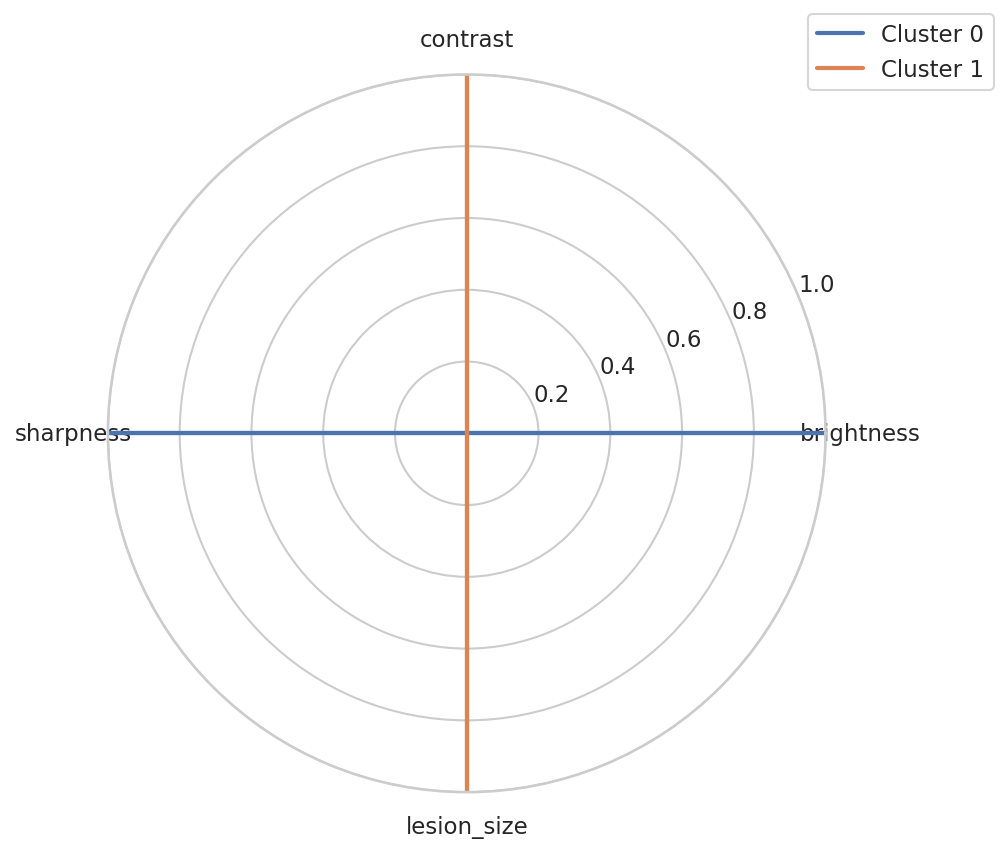

Cached image features: 13256 unique images
✓ Section 9 complete


In [11]:
IMAGE_FEATURE_CACHE = {}


def compute_image_features(image_path, image_dir=None):
    """Compute cached brightness, contrast, sharpness, and foreground fraction from a grayscale image."""
    if image_path in IMAGE_FEATURE_CACHE:
        return IMAGE_FEATURE_CACHE[image_path]

    try:
        img = Image.open(image_path).convert('L').resize((224, 224))
        arr = np.asarray(img, dtype=np.float32)
    except Exception:
        features = {
            'brightness': np.nan,
            'contrast': np.nan,
            'sharpness': np.nan,
            'lesion_size': np.nan
        }
        IMAGE_FEATURE_CACHE[image_path] = features
        return features

    brightness = float(arr.mean() / 255.0)
    contrast = float(arr.std() / 255.0)

    if ndimage is not None:
        sharpness = float(np.var(ndimage.laplace(arr)))
    else:
        gy, gx = np.gradient(arr)
        sharpness = float(np.var(gx) + np.var(gy))

    # Faster foreground proxy than Otsu.
    if arr.std() > 0:
        thresh = arr.mean()
        lesion_size = float((arr > thresh).mean())
    else:
        lesion_size = 0.0

    features = {
        'brightness': brightness,
        'contrast': contrast,
        'sharpness': sharpness,
        'lesion_size': lesion_size
    }

    IMAGE_FEATURE_CACHE[image_path] = features
    return features


def profile_clusters(clustered_df, model_name, config):
    """Summarize clinical/image characteristics and calibration for each failure cluster."""
    rows = []

    if len(clustered_df) == 0:
        return pd.DataFrame()

    class_map = dict(enumerate(config['class_names']))

    for cluster_id, group in tqdm(
        clustered_df.groupby('cluster'),
        desc=f'profile {model_name}',
        leave=False
    ):
        probs = np.stack(
            group['prob_vector'].apply(lambda x: np.fromstring(x, sep=','))
        )
        labels_arr = group['true_label'].values

        pairs = list(zip(group['true_label'], group['pred_label']))
        dominant_pair = Counter(pairs).most_common(1)[0][0]

        feature_rows = [
            compute_image_features(p, config.get('image_dir'))
            for p in group['image_path']
        ]
        features = pd.DataFrame(feature_rows)

        row = {
            'cluster': int(cluster_id),
            'n_samples': int(len(group)),
            'true_class_distribution': dict(Counter(group['true_label'].map(class_map))),
            'pred_class_distribution': dict(Counter(group['pred_label'].map(class_map))),
            'dominant_confusion': (
                f"{config['class_names'][dominant_pair[0]]}"
                f"->{config['class_names'][dominant_pair[1]]}"
            ),
            'mean_confidence': float(group['confidence'].mean()),
            'std_confidence': float(group['confidence'].std(ddof=0)),
            'per_cluster_ece': compute_ece(
                probs,
                labels_arr,
                config.get('ece_bins', 15)
            ),
        }

        for feat in ['brightness', 'contrast', 'sharpness', 'lesion_size']:
            row[f'{feat}_mean'] = float(features[feat].mean())
            row[f'{feat}_std'] = float(features[feat].std(ddof=0))

        rows.append(row)

    profile_df = pd.DataFrame(rows)

    print(
        profile_df[
            ['cluster', 'n_samples', 'dominant_confusion',
             'mean_confidence', 'per_cluster_ece']
        ].to_string(index=False)
    )

    feats = [
        'brightness_mean',
        'contrast_mean',
        'sharpness_mean',
        'lesion_size_mean'
    ]

    radar = profile_df[['cluster'] + feats].copy()

    for feat in feats:
        mn, mx = radar[feat].min(), radar[feat].max()
        if pd.isna(mn) or pd.isna(mx) or mx == mn:
            radar[feat] = 0.5
        else:
            radar[feat] = (radar[feat] - mn) / (mx - mn)

    labels = ['brightness', 'contrast', 'sharpness', 'lesion_size']
    angles = np.linspace(0, 2 * np.pi, len(labels), endpoint=False).tolist()
    angles += angles[:1]

    fig = plt.figure(figsize=(7, 7), dpi=150)
    ax = fig.add_subplot(111, polar=True)

    for _, row in radar.iterrows():
        values = [row[f] for f in feats]
        values += values[:1]

        ax.plot(
            angles,
            values,
            linewidth=2,
            label=f"Cluster {int(row['cluster'])}"
        )
        ax.fill(angles, values, alpha=0.08)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels)
    ax.set_ylim(0, 1)
    ax.legend(loc='upper right', bbox_to_anchor=(1.25, 1.1))

    plt.tight_layout()
    plt.savefig(
        f"{config['figures_dir']}/radar_{model_name}.png",
        dpi=300,
        bbox_inches='tight'
    )
    plt.show()

    return profile_df


all_profiles = {}

for model_name in MODELS:
    print(f'\nProfiling clusters: {model_name}')

    profile_df = profile_clusters(
        all_clustered[model_name],
        model_name,
        CONFIG
    )

    all_profiles[model_name] = profile_df

    profile_df.to_csv(
        f'{CONFIG["results_dir"]}/profile_chexpert_{model_name}.csv',
        index=False
    )

print(f"Cached image features: {len(IMAGE_FEATURE_CACHE)} unique images")
print("✓ Section 9 complete")

In [12]:
# ── Degradation guard thresholds (reads from CONFIG) ─────────────────
# Tiered absolute-drop thresholds, aligned with aptos:
# CONFIG['guard_f1_max_drop'], CONFIG['guard_acc_max_drop'], CONFIG['guard_ece_max_rise']  (strict tier)
# CONFIG['guard_weak_f1_max_drop'], CONFIG['guard_weak_acc_max_drop'], CONFIG['guard_weak_ece_max_rise']  (weak tier)
# Weak tier applies automatically when CONFIG['guard_weak_baseline_f1'] > baseline val F1.


def build_failure_aware_dataset(train_df, clustered_df, profile_df, config, strategy='both'):
    """Create a retraining dataframe using cluster-informed weighting and/or selective augmentation."""
    out = train_df.copy()
    out['is_augmented'] = False
    out['sample_weight'] = 1.0

    if clustered_df is None or len(clustered_df) == 0 or profile_df is None or len(profile_df) == 0:
        return out

    cluster_counts     = clustered_df['cluster'].value_counts().to_dict()
    mean_cluster_count = np.mean(list(cluster_counts.values())) if cluster_counts else 1.0

    cluster_alpha = {
        k: max(1.0, v / max(mean_cluster_count, 1e-8))
        for k, v in cluster_counts.items()
    }

    path_to_cluster = dict(zip(clustered_df['image_path'], clustered_df['cluster']))

    cluster_to_true_labels = (
        clustered_df
        .groupby('cluster')['true_label']
        .apply(lambda s: set(s.tolist()))
        .to_dict()
    )

    path_overlap = out['image_path'].isin(set(clustered_df['image_path'])).sum()

    if strategy in ['selective', 'both']:
        high_clusters = [
            k for k, v in cluster_counts.items()
            if v > mean_cluster_count
        ]

        if len(high_clusters) == 0:
            high_clusters = list(cluster_counts.keys())

        high_paths = set(
            clustered_df[clustered_df['cluster'].isin(high_clusters)]['image_path']
        )

        source = out[out['image_path'].isin(high_paths)].copy()

        if len(source) == 0:
            high_labels = set()
            for cluster_id in high_clusters:
                high_labels.update(cluster_to_true_labels.get(cluster_id, set()))

            source = out[out['label'].isin(high_labels)].copy()
            print(
                "No train/test path overlap for selective augmentation; "
                f"using high-error true labels {sorted(high_labels)}."
            )

        max_aug_source = config.get('max_aug_source', 300)

        if len(source) > max_aug_source:
            if source['label'].nunique() > 1:
                source, _ = train_test_split(
                    source,
                    train_size=max_aug_source,
                    random_state=config['seed'],
                    stratify=source['label']
                )
                source = source.reset_index(drop=True)
            else:
                source = source.sample(
                    n=max_aug_source,
                    random_state=config['seed']
                ).reset_index(drop=True)
            print(f"Limited selective augmentation source to {max_aug_source} samples.")

        augmented = []
        for _ in range(config.get('aug_multiplier', 3)):
            aug = source.copy()
            aug['is_augmented'] = True
            augmented.append(aug)

        if augmented:
            out = pd.concat([out] + augmented, ignore_index=True)

        print(
            f"Selective augmentation: {len(source)} source rows, "
            f"{sum(len(a) for a in augmented)} augmented rows added"
        )

    if strategy in ['weighted', 'both']:
        if path_overlap > 0:
            out['sample_weight'] = out['image_path'].map(
                lambda p: cluster_alpha.get(path_to_cluster.get(p, None), 1.0)
            )
        else:
            label_weights = defaultdict(lambda: 1.0)
            for cluster_id, alpha in cluster_alpha.items():
                for label in cluster_to_true_labels.get(cluster_id, set()):
                    label_weights[label] = max(label_weights[label], alpha)

            out['sample_weight'] = out['label'].map(lambda y: label_weights[y])
            print(
                "No train/test path overlap for weighting; "
                f"using label-level failure weights {dict(label_weights)}."
            )

        print(
            f"Weighted sampling: sample weights range "
            f"{out['sample_weight'].min():.2f}–{out['sample_weight'].max():.2f}"
        )

    return out


def _run_degradation_guard(model, model_name, val_loader, criterion_retrain,
                            baseline_val_metrics, config, device,
                            baseline_ckpt, retrained_ckpt):
    """
    Evaluate retrained model on val set and compare against baseline.
    Uses tiered ABSOLUTE-DROP thresholds based on baseline performance
    (aligned with aptos): a weaker baseline gets more tolerance for drop.
    If ANY check fails → revert model weights to baseline in-place.

    Returns
    -------
    guard_result : dict
        guard_triggered : bool
        kept            : 'retrained' | 'baseline'
        checks          : dict of check-name → description string
        reason          : str of failed checks joined by ' | ', or None
    """
    val_retrained = evaluate(
        model, val_loader, criterion_retrain,
        device, config['num_classes'], config['class_names']
    )

    baseline_f1 = baseline_val_metrics['val_f1']
    use_weak = baseline_f1 < config.get('guard_weak_baseline_f1', 0.55)

    if use_weak:
        max_f1_drop  = config.get('guard_weak_f1_max_drop', 0.04)
        max_acc_drop = config.get('guard_weak_acc_max_drop', 0.04)
        max_ece_rise = config.get('guard_weak_ece_max_rise', 0.04)
        tier = 'WEAK'
    else:
        max_f1_drop  = config.get('guard_f1_max_drop', 0.02)
        max_acc_drop = config.get('guard_acc_max_drop', 0.02)
        max_ece_rise = config.get('guard_ece_max_rise', 0.025)
        tier = 'STRICT'

    f1_drop  = baseline_val_metrics['val_f1']  - val_retrained['f1']
    acc_drop = baseline_val_metrics['val_acc'] - val_retrained['accuracy']
    ece_rise = val_retrained['ece']            - baseline_val_metrics['val_ece']

    checks = {
        'f1_ok' : (
            f1_drop <= max_f1_drop,
            f"val F1 drop {f1_drop:+.4f} "
            f"({'≤' if f1_drop <= max_f1_drop else '>'} {max_f1_drop} [{tier}])"
        ),
        'acc_ok': (
            acc_drop <= max_acc_drop,
            f"val acc drop {acc_drop:+.4f} "
            f"({'≤' if acc_drop <= max_acc_drop else '>'} {max_acc_drop} [{tier}])"
        ),
        'ece_ok': (
            ece_rise <= max_ece_rise,
            f"val ECE rise {ece_rise:+.4f} "
            f"({'≤' if ece_rise <= max_ece_rise else '>'} {max_ece_rise} [{tier}])"
        ),
    }

    print(f"\n  Guard checks — {model_name}:")
    for name, (passed, msg) in checks.items():
        print(f"    {'✓' if passed else '✗'}  {msg}")

    failed = [msg for passed, msg in checks.values() if not passed]

    if failed:
        print(f"\n  ⚠️  Guard triggered — reverting {model_name} to baseline")
        model.load_state_dict(torch.load(baseline_ckpt, map_location=device))
        # overwrite retrained ckpt so downstream loads still work
        torch.save(model.state_dict(), retrained_ckpt)
        return {
            'guard_triggered': True,
            'kept'           : 'baseline',
            'checks'         : {k: v[1] for k, v in checks.items()},
            'reason'         : ' | '.join(failed),
        }

    print(f"\n  ✓ All checks passed — keeping retrained {model_name}")
    return {
        'guard_triggered': False,
        'kept'           : 'retrained',
        'checks'         : {k: v[1] for k, v in checks.items()},
        'reason'         : None,
    }


def retrain_model(model_name, train_loader_new, val_loader,
                  class_weights, config, baseline_val_metrics=None):
    """
    Warm-start from best baseline checkpoint and fine-tune with
    failure-aware data.

    Parameters
    ----------
    baseline_val_metrics : dict or None
        Keys: 'val_f1', 'val_acc', 'val_ece' from baseline evaluation.
        Pass None to skip the degradation guard entirely.

    Returns
    -------
    model        : best model state (baseline or retrained)
    history      : training history dict
    guard_result : dict with guard decision details
    """
    baseline_ckpt  = Path(config['checkpoint_dir']) / f'best_chexpert_{model_name}.pth'
    retrained_ckpt = Path(config['checkpoint_dir']) / f'retrained_chexpert_{model_name}.pth'

    # ── Warm start ───────────────────────────────────────────────────
    model = get_model(model_name, config['num_classes'], pretrained=False)
    model.load_state_dict(torch.load(baseline_ckpt, map_location=device))

    criterion_retrain = nn.CrossEntropyLoss(weight=class_weights.to(device))

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=config.get('retrain_lr', 5e-5),
        weight_decay=config['weight_decay']
    )

    retrain_epochs   = config.get('retrain_epochs', 1)
    retrain_patience = config.get('retrain_patience', 1)

    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=retrain_epochs
    )

    scaler           = GradScaler()
    history          = defaultdict(list)
    best_f1          = -np.inf
    patience_counter = 0

    # ── Training loop ────────────────────────────────────────────────
    for epoch in range(1, retrain_epochs + 1):
        print(f"  Retrain epoch {epoch}/{retrain_epochs} — {model_name}")

        train_loss, train_acc = train_one_epoch(
            model, train_loader_new, optimizer,
            criterion_retrain, scaler, device
        )

        val_metrics = evaluate(
            model, val_loader, criterion_retrain,
            device, config['num_classes'], config['class_names']
        )

        scheduler.step()

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_metrics['loss'])
        history['val_acc'].append(val_metrics['accuracy'])
        history['val_f1'].append(val_metrics['f1'])
        history['val_auc'].append(val_metrics['auc'])

        print(
            f"    loss={val_metrics['loss']:.4f}  "
            f"acc={val_metrics['accuracy']:.4f}  "
            f"F1={val_metrics['f1']:.4f}  "
            f"AUC={val_metrics['auc']:.4f}"
        )

        if val_metrics['f1'] > best_f1:
            best_f1          = val_metrics['f1']
            patience_counter = 0
            torch.save(model.state_dict(), retrained_ckpt)
            print(f"    ✓ checkpoint saved  (best val F1={best_f1:.4f})")
        else:
            patience_counter += 1
            print(f"    patience {patience_counter}/{retrain_patience}")
            if patience_counter >= retrain_patience:
                print(f"  Early stop at epoch {epoch}")
                break

    # ── Load best retrained weights before guard ─────────────────────
    model.load_state_dict(torch.load(retrained_ckpt, map_location=device))

    # ── Degradation guard ────────────────────────────────────────────
    if baseline_val_metrics is not None:
        guard_result = _run_degradation_guard(
            model, model_name, val_loader, criterion_retrain,
            baseline_val_metrics, config, device,
            baseline_ckpt, retrained_ckpt
        )
    else:
        print(f"\n  ⚠️  baseline_val_metrics not supplied — guard skipped for {model_name}")
        guard_result = {
            'guard_triggered': False,
            'kept'           : 'retrained',
            'checks'         : {},
            'reason'         : 'guard skipped — no baseline metrics supplied',
        }

    return model, dict(history), guard_result


# ── Retraining loop ──────────────────────────────────────────────────
improvement_results   = []
retrain_histories     = {}
retrained_confusions  = {}
retrained_predictions = {}
guard_log             = []          # ← new: full audit trail

for model_name in tqdm(MODELS, desc='Retraining'):

    family   = get_model_family(model_name)
    strategy = {
        'transformer': 'both',
        'efficient'  : 'weighted',
        'cnn'        : 'selective',
    }[family]

    print(f'\n{"═"*60}')
    print(f'Retraining → {model_name}  |  family={family}  |  strategy={strategy}')
    print(f'{"═"*60}')

    # ── Failure-aware training set ───────────────────────────────────
    new_train_df = build_failure_aware_dataset(
        train_df,
        all_clustered[model_name],
        all_profiles[model_name],
        CONFIG,
        strategy
    )

    new_train_loader, _, _, _ = get_dataloaders(
        new_train_df,
        test_df,
        CONFIG,
        val_df=val_loader.dataset.df
    )

    # ── Baseline val metrics for guard ───────────────────────────────
    # Prefer stored val metrics; fall back to test metrics if not saved
    baseline_row = baseline_df[baseline_df['model'] == model_name].iloc[0]

    baseline_val_metrics = {
        'val_f1' : baseline_row.get('val_f1',  baseline_row['test_f1']),
        'val_acc': baseline_row.get('val_acc', baseline_row['test_accuracy']),
        'val_ece': baseline_row.get('val_ece', baseline_row['test_ece']),
    }

    # ── Retrain + guard ──────────────────────────────────────────────
    retrained_model, history, guard_result = retrain_model(
        model_name,
        new_train_loader,
        val_loader,
        class_weights,
        CONFIG,
        baseline_val_metrics=baseline_val_metrics
    )

    retrain_histories[model_name] = history
    guard_log.append({**guard_result, 'model': model_name})

    # ── Test set evaluation ──────────────────────────────────────────
    retrain_metrics = evaluate(
        retrained_model,
        test_loader,
        criterion,
        device,
        CONFIG['num_classes'],
        CONFIG['class_names']
    )

    retrained_predictions[model_name] = retrain_metrics

    retrained_confusions[model_name] = confusion_matrix(
        retrain_metrics['labels'],
        retrain_metrics['preds'],
        labels=list(range(CONFIG['num_classes']))
    )

    # ── Deltas ───────────────────────────────────────────────────────
    delta_acc = (
        (retrain_metrics['accuracy'] - baseline_row['test_accuracy'])
        / max(baseline_row['test_accuracy'], 1e-8) * 100
    )
    delta_f1 = (
        (retrain_metrics['f1'] - baseline_row['test_f1'])
        / max(baseline_row['test_f1'], 1e-8) * 100
    )
    delta_auc = (
        (retrain_metrics['auc'] - baseline_row['test_auc'])
        / max(baseline_row['test_auc'], 1e-8) * 100
    )
    delta_ece = retrain_metrics['ece'] - baseline_row['test_ece']

    improvement_results.append({
        'model'          : model_name,
        'family'         : family,
        'strategy'       : strategy,
        # guard columns
        'guard_triggered': guard_result['guard_triggered'],
        'guard_kept'     : guard_result['kept'],
        'guard_reason'   : guard_result['reason'],
        # metrics
        'baseline_acc'   : baseline_row['test_accuracy'],
        'retrained_acc'  : retrain_metrics['accuracy'],
        'delta_acc_pct'  : delta_acc,
        'baseline_f1'    : baseline_row['test_f1'],
        'retrained_f1'   : retrain_metrics['f1'],
        'delta_f1_pct'   : delta_f1,
        'baseline_auc'   : baseline_row['test_auc'],
        'retrained_auc'  : retrain_metrics['auc'],
        'delta_auc_pct'  : delta_auc,
        'baseline_ece'   : baseline_row['test_ece'],
        'retrained_ece'  : retrain_metrics['ece'],
        'delta_ece'      : delta_ece,
    })

    del retrained_model
    torch.cuda.empty_cache()
    gc.collect()


# ── Save ─────────────────────────────────────────────────────────────
improvement_df = pd.DataFrame(improvement_results)
improvement_df.to_csv(
    f'{CONFIG["results_dir"]}/improvement_chexpert.csv', index=False
)

guard_df = pd.DataFrame(guard_log)
guard_df.to_csv(
    f'{CONFIG["results_dir"]}/guard_log_chexpert.csv', index=False
)

# ── Guard summary ─────────────────────────────────────────────────────
triggered = guard_df[guard_df['guard_triggered']]
passed    = guard_df[~guard_df['guard_triggered']]

print(f'\n{"═"*60}')
print(f'GUARD SUMMARY')
print(f'{"═"*60}')
print(f'  Passed   (retrained kept) : {len(passed)}/{len(MODELS)}')
print(f'  Triggered (reverted)      : {len(triggered)}/{len(MODELS)}')
if len(triggered) > 0:
    print(f'\n  Reverted models:')
    for _, row in triggered.iterrows():
        print(f'    ⚠️  {row["model"]:35s}  {row["reason"]}')

# ── Improvement summary ───────────────────────────────────────────────
print(f'\n{"═"*60}')
print('IMPROVEMENT SUMMARY')
print(f'{"═"*60}')
print(improvement_df[[
    'model', 'strategy', 'guard_kept',
    'baseline_acc', 'retrained_acc', 'delta_acc_pct',
    'baseline_f1',  'retrained_f1',  'delta_f1_pct',
    'delta_ece',
]].to_string(index=False))

print('\n✓ Section 10 complete')

Retraining:   0%|          | 0/1 [00:00<?, ?it/s]


════════════════════════════════════════════════════════════
Retraining → resnet50  |  family=cnn  |  strategy=selective
════════════════════════════════════════════════════════════
Limited selective augmentation source to 300 samples.
Selective augmentation: 300 source rows, 900 augmented rows added
resnet50: 23.52M params (23.52M trainable)
  Retrain epoch 1/10 — resnet50


train:   0%|          | 0/3154 [00:00<?, ?it/s]

eval:   0%|          | 0/625 [00:00<?, ?it/s]

    loss=0.9245  acc=0.6112  F1=0.5691  AUC=0.8375
    ✓ checkpoint saved  (best val F1=0.5691)
  Retrain epoch 2/10 — resnet50


...

    loss=0.6888  acc=0.6970  F1=0.6670  AUC=0.8980
    ✓ checkpoint saved  (best val F1=0.6670)


eval:   0%|          | 0/625 [00:00<?, ?it/s]


  Guard checks — resnet50:
    ✓  val F1 drop -0.1435 (≤ 0.04 [WEAK])
    ✓  val acc drop -0.1108 (≤ 0.04 [WEAK])
    ✓  val ECE rise -0.0642 (≤ 0.04 [WEAK])

  ✓ All checks passed — keeping retrained resnet50


eval:   0%|          | 0/5 [00:00<?, ?it/s]


════════════════════════════════════════════════════════════
GUARD SUMMARY
════════════════════════════════════════════════════════════
  Passed   (retrained kept) : 1/1
  Triggered (reverted)      : 0/1

════════════════════════════════════════════════════════════
IMPROVEMENT SUMMARY
════════════════════════════════════════════════════════════
   model  strategy guard_kept  baseline_acc  retrained_acc  delta_acc_pct  baseline_f1  retrained_f1  delta_f1_pct  delta_ece
resnet50 selective  retrained      0.586207       0.572414      -2.352941     0.523538      0.541437      3.418894    0.08287

✓ Section 10 complete


In [13]:
# =====================================
# Section 10b: Untargeted Control Retraining
# Aligned with aptos pipeline — validates that failure-aware gains are
# not just an artifact of extra retraining epochs alone.
# =====================================
if 'baseline_df' not in globals():
    print("Warning: baseline_df not found — skipping Section 10b")
else:
    def retrain_untargeted(model_name, train_loader, val_loader, class_weights, config):
        """Untargeted control: warm-start from baseline and retrain with the same
        unmodified training set (no failure-informed weighting/augmentation)."""
        baseline_ckpt = Path(config['checkpoint_dir']) / f"best_chexpert_{model_name}.pth"
        control_ckpt = Path(config['checkpoint_dir']) / f"control_chexpert_{model_name}.pth"

        model = get_model(model_name, config['num_classes'], pretrained=False)
        model.load_state_dict(torch.load(baseline_ckpt, map_location=device))
        model.train()

        criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))
        optimizer = torch.optim.AdamW(
            model.parameters(),
            lr=config.get('retrain_lr', 5e-5),
            weight_decay=config['weight_decay']
        )
        retrain_epochs = config.get('retrain_epochs', 10)
        retrain_patience = config.get('retrain_patience', 3)
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=retrain_epochs)
        scaler = GradScaler()

        best_f1, patience_counter = -np.inf, 0

        for epoch in range(1, retrain_epochs + 1):
            print(f"  Control epoch {epoch}/{retrain_epochs} — {model_name}")
            train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, scaler, device)
            val_metrics = evaluate(model, val_loader, criterion, device, config['num_classes'], config['class_names'])
            scheduler.step()

            if val_metrics['f1'] > best_f1:
                best_f1 = val_metrics['f1']
                patience_counter = 0
                torch.save(model.state_dict(), control_ckpt)
                print(f"    Checkpoint saved (val F1={best_f1:.4f})")
            else:
                patience_counter += 1
                if patience_counter >= retrain_patience:
                    print(f"    Early stopping at epoch {epoch}")
                    break

        model.load_state_dict(torch.load(control_ckpt, map_location=device))
        test_metrics = evaluate(model, test_loader, criterion, device, config['num_classes'], config['class_names'])

        del model
        torch.cuda.empty_cache()
        gc.collect()
        return test_metrics


    untargeted_results = []
    print(f"\nStarting untargeted control for {len(MODELS)} models")

    for model_name in tqdm(MODELS, desc='Control Retraining'):
        try:
            print(f"\nUntargeted control → {model_name}")
            ctrl_metrics = retrain_untargeted(model_name, train_loader, val_loader, class_weights, CONFIG)

            baseline_row = baseline_df[baseline_df['model'] == model_name].iloc[0]
            delta_f1 = (ctrl_metrics['f1'] - baseline_row['test_f1']) / max(baseline_row['test_f1'], 1e-8) * 100
            delta_acc = (ctrl_metrics['accuracy'] - baseline_row['test_accuracy']) / max(baseline_row['test_accuracy'], 1e-8) * 100
            delta_ece = ctrl_metrics['ece'] - baseline_row['test_ece']

            untargeted_results.append({
                'model': model_name,
                'dataset': 'chexpert',
                'ctrl_f1': ctrl_metrics['f1'],
                'ctrl_acc': ctrl_metrics['accuracy'],
                'ctrl_auc': ctrl_metrics['auc'],
                'ctrl_ece': ctrl_metrics['ece'],
                'baseline_f1': baseline_row['test_f1'],
                'baseline_acc': baseline_row['test_accuracy'],
                'baseline_ece': baseline_row['test_ece'],
                'delta_f1_ctrl_pct': delta_f1,
                'delta_acc_ctrl_pct': delta_acc,
                'delta_ece_ctrl': delta_ece,
            })
            print(f"  Control done → ΔF1={delta_f1:+.2f}%")

        except Exception as e:
            print(f"  Failed untargeted {model_name}: {type(e).__name__}: {e}")

    untargeted_df = pd.DataFrame(untargeted_results)
    save_path = f"{CONFIG['results_dir']}/untargeted_control_chexpert.csv"
    untargeted_df.to_csv(save_path, index=False)
    print(f"\nUntargeted control completed: {len(untargeted_df)} models")
    print(f"Results saved: {save_path}")

    print("\n" + "-" * 80)
    print("UNTARGETED CONTROL SUMMARY")
    print("-" * 80)
    print(untargeted_df[[
        'model', 'ctrl_f1', 'delta_f1_ctrl_pct', 'ctrl_ece', 'delta_ece_ctrl'
    ]].round(4).to_string(index=False))

    if len(untargeted_df) > 0:
        avg_improvement = untargeted_df['delta_f1_ctrl_pct'].mean()
        print(f"\nAverage F1 improvement (retraining-only): {avg_improvement:+.3f}%")
        if avg_improvement < 0.1:
            print("Minimal gain from retraining alone — stability confirmed")
        else:
            print(f"Retraining alone improves F1 by {avg_improvement:+.3f}% — interpret failure-aware gains cautiously")

print("✓ Section 10b complete — Untargeted control")



Starting untargeted control for 1 models


Control Retraining:   0%|          | 0/1 [00:00<?, ?it/s]


Untargeted control → resnet50
resnet50: 23.52M params (23.52M trainable)
  Control epoch 1/10 — resnet50


train:   0%|          | 0/2500 [00:00<?, ?it/s]

eval:   0%|          | 0/625 [00:00<?, ?it/s]

...

    Checkpoint saved (val F1=0.4356)
  Control epoch 10/10 — resnet50


train:   0%|          | 0/2500 [00:00<?, ?it/s]

eval:   0%|          | 0/625 [00:00<?, ?it/s]

eval:   0%|          | 0/5 [00:00<?, ?it/s]

  Control done → ΔF1=-1.40%

Untargeted control completed: 1 models
Results saved: /kaggle/working/results/untargeted_control_chexpert.csv

--------------------------------------------------------------------------------
UNTARGETED CONTROL SUMMARY
--------------------------------------------------------------------------------
   model  ctrl_f1  delta_f1_ctrl_pct  ctrl_ece  delta_ece_ctrl
resnet50   0.5162            -1.4046    0.2169          0.1217

Average F1 improvement (retraining-only): -1.405%
Minimal gain from retraining alone — stability confirmed
✓ Section 10b complete — Untargeted control


Best model selected for detailed figures: resnet50


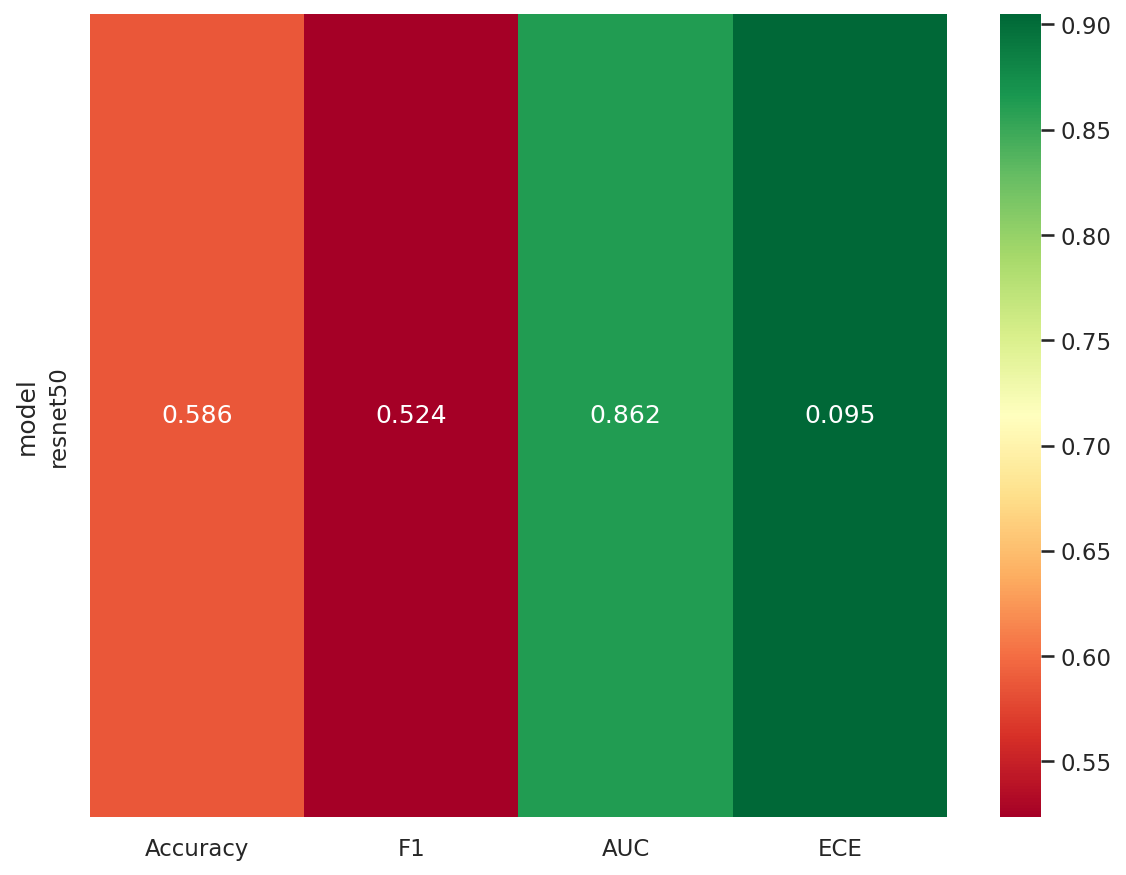

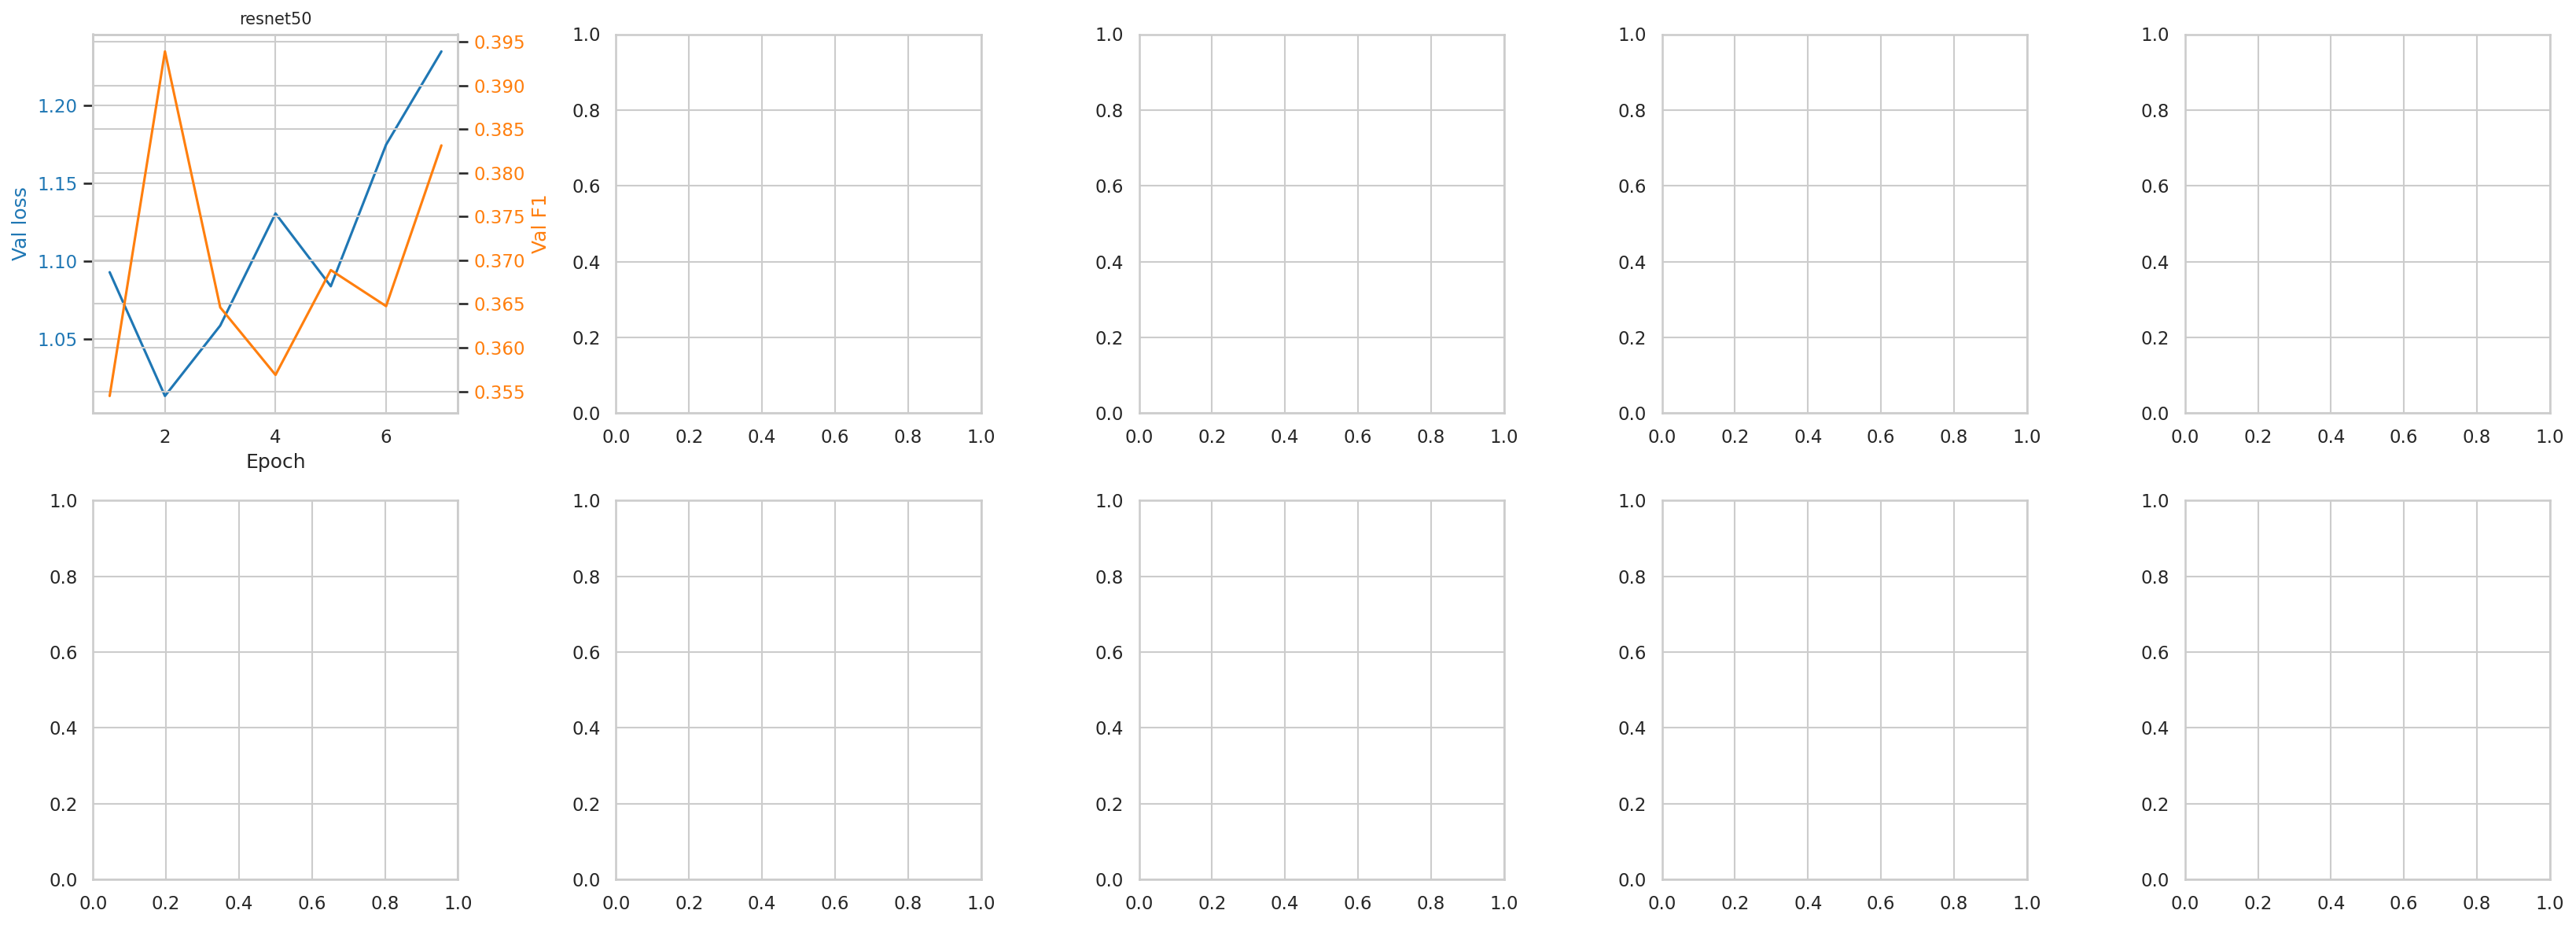

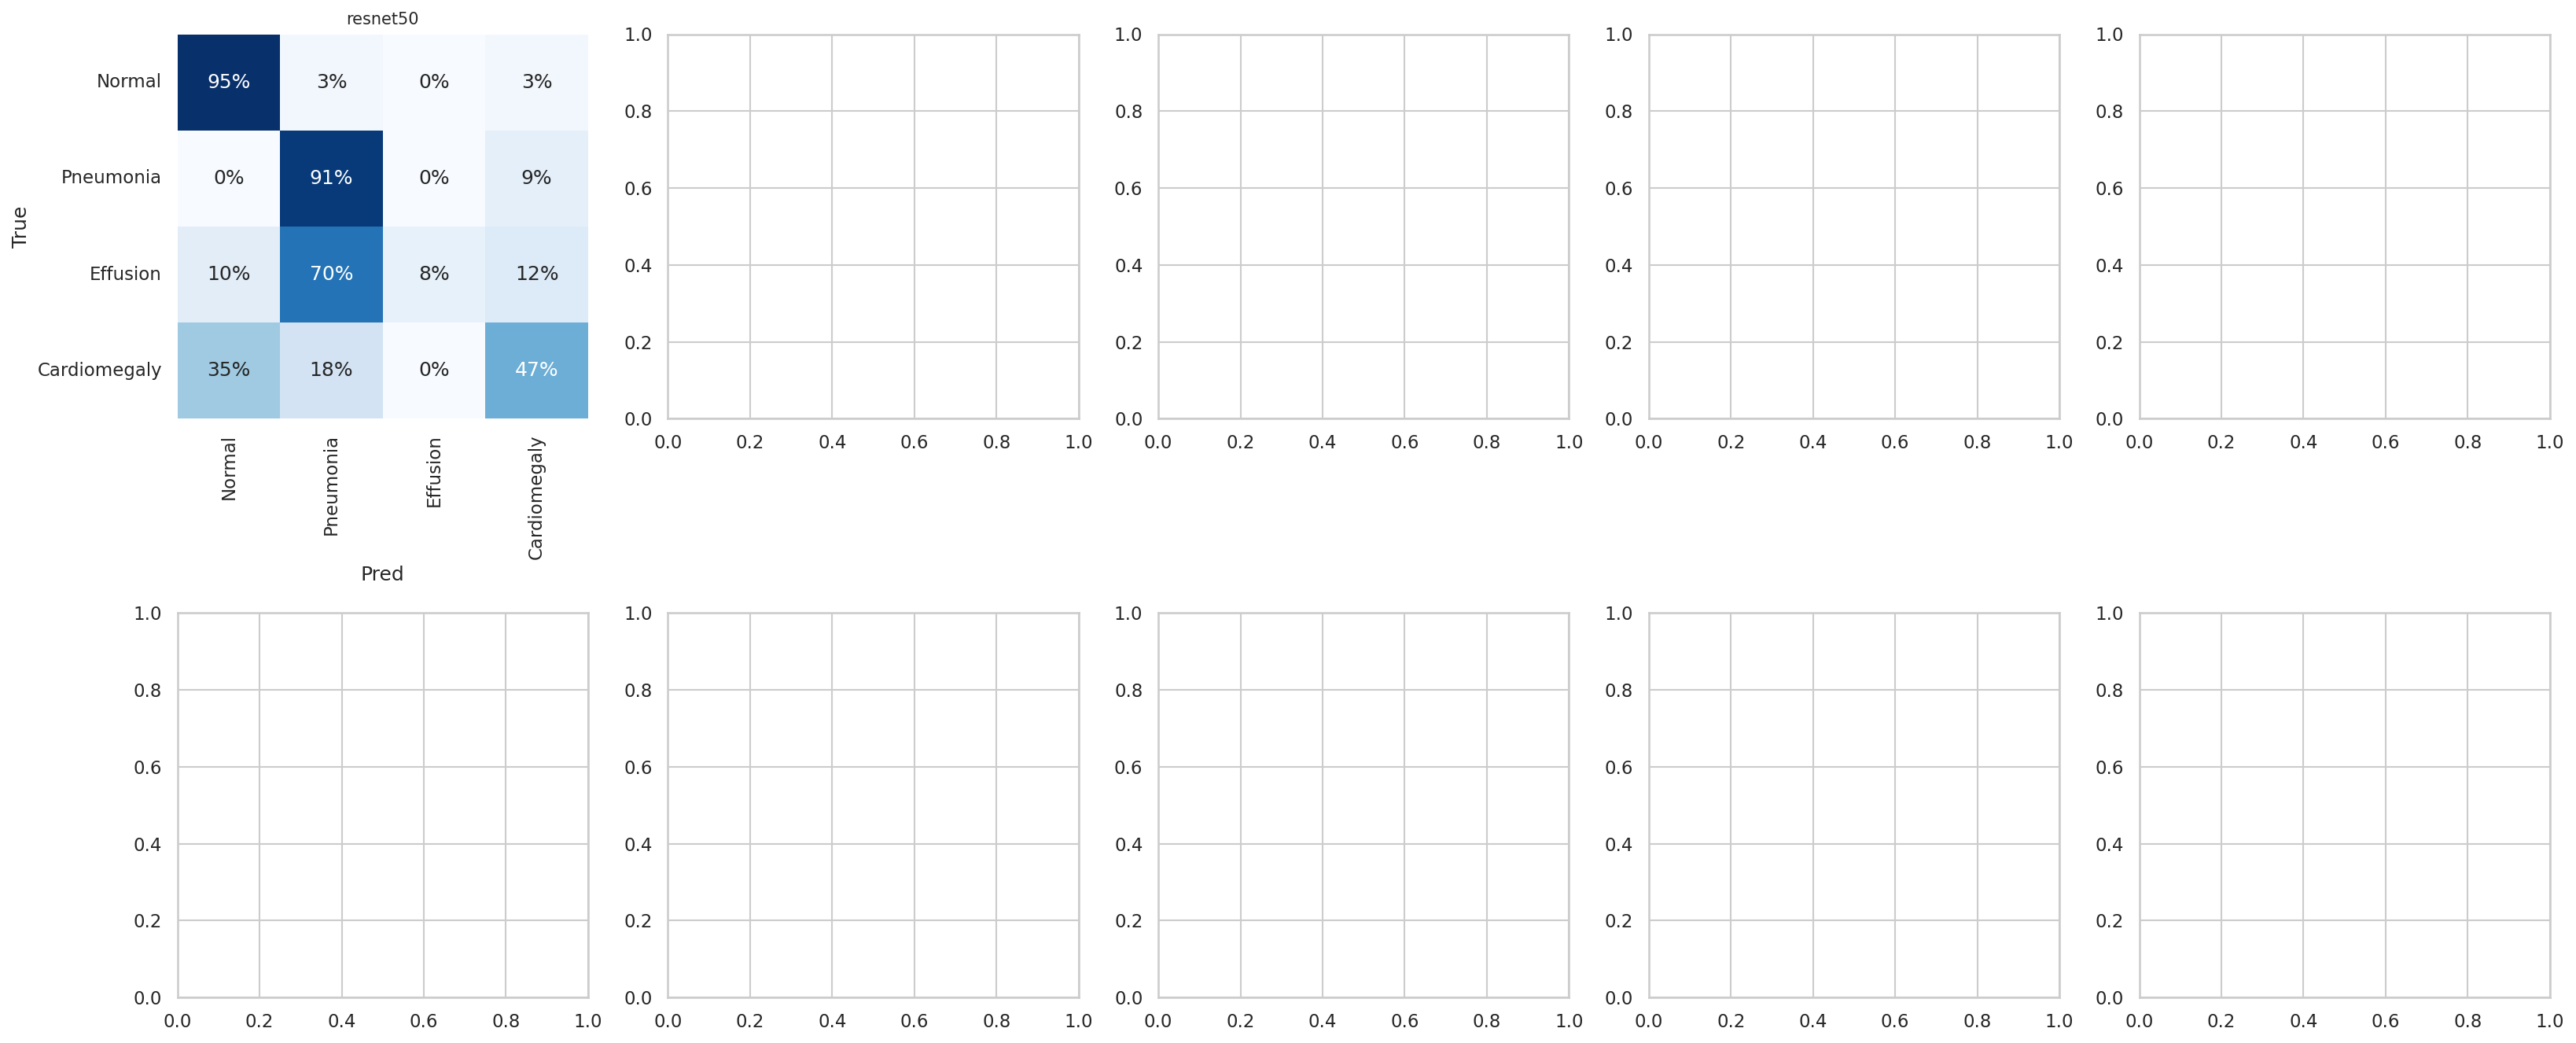

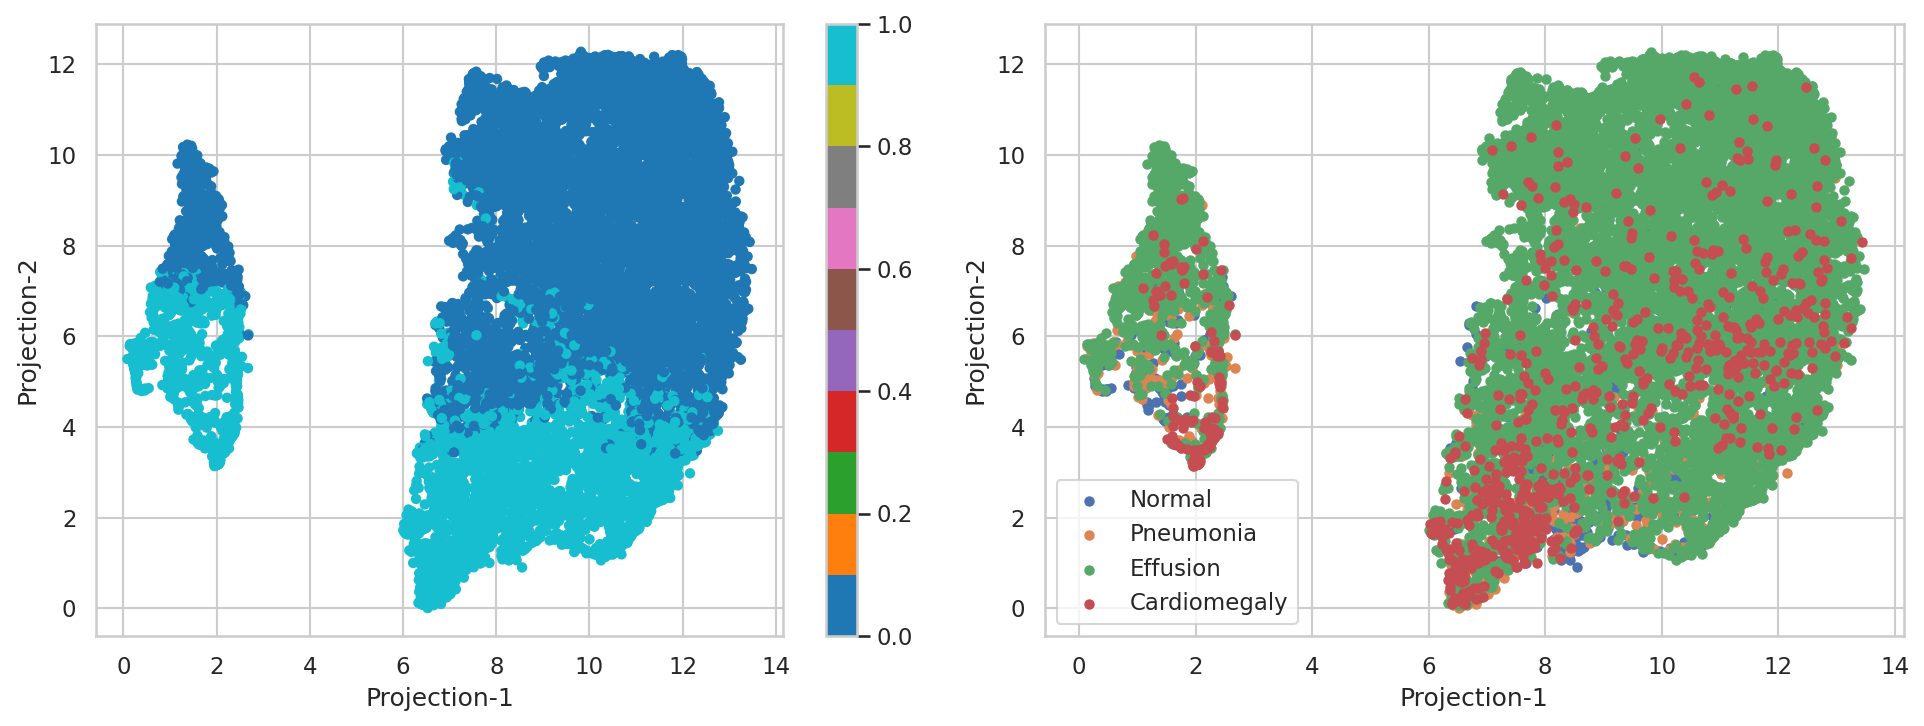

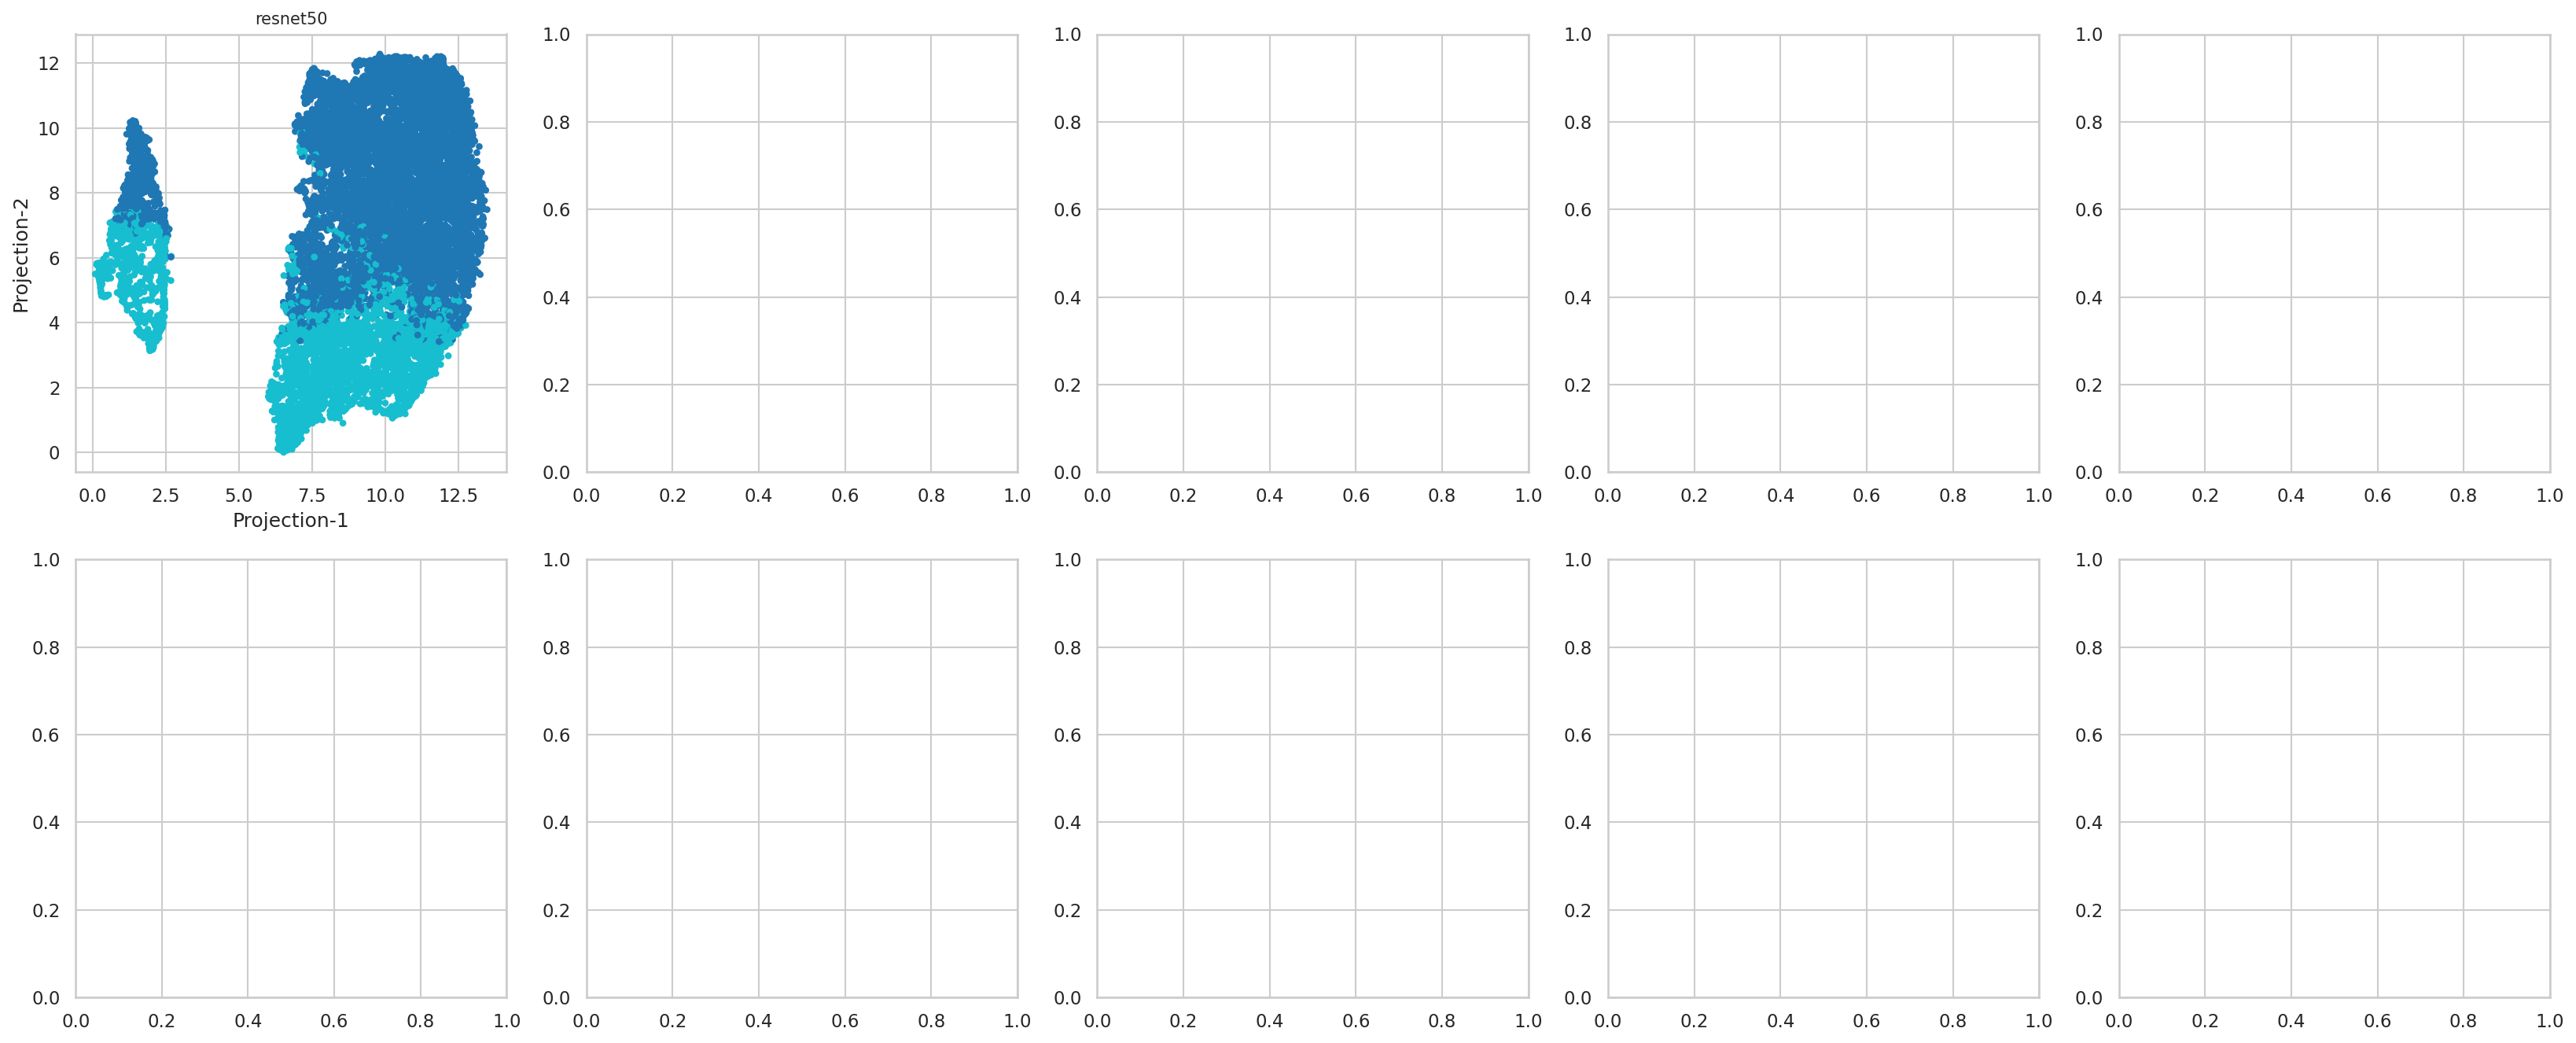

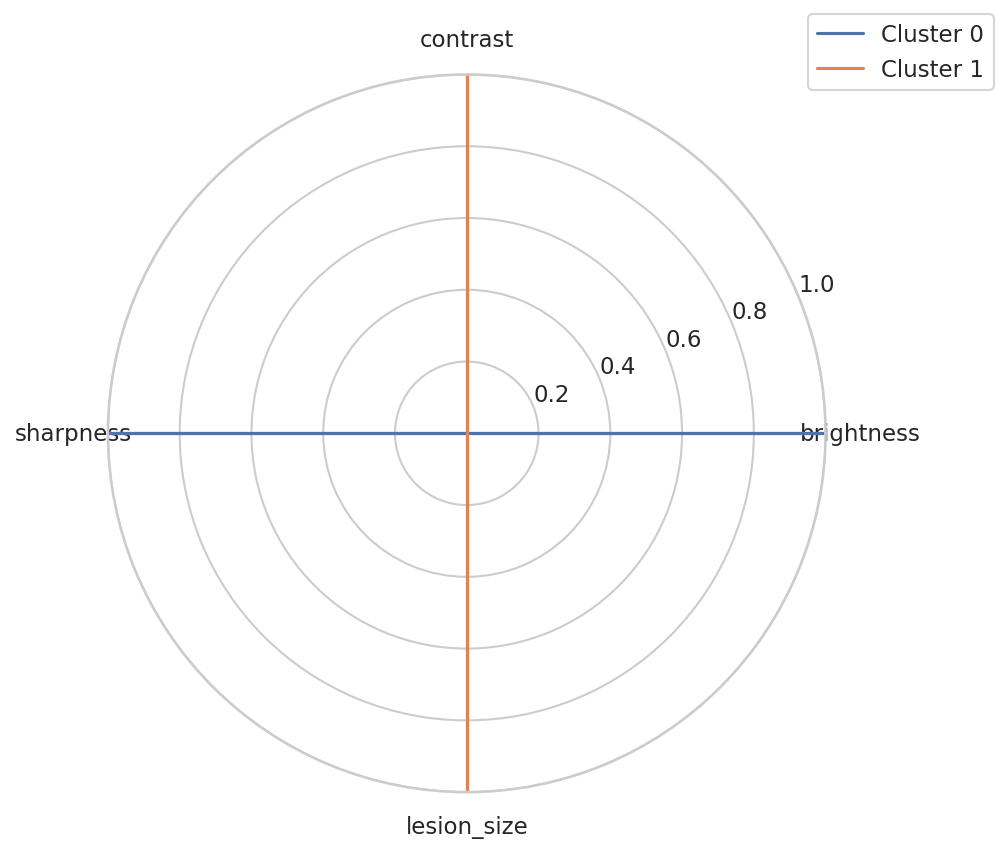

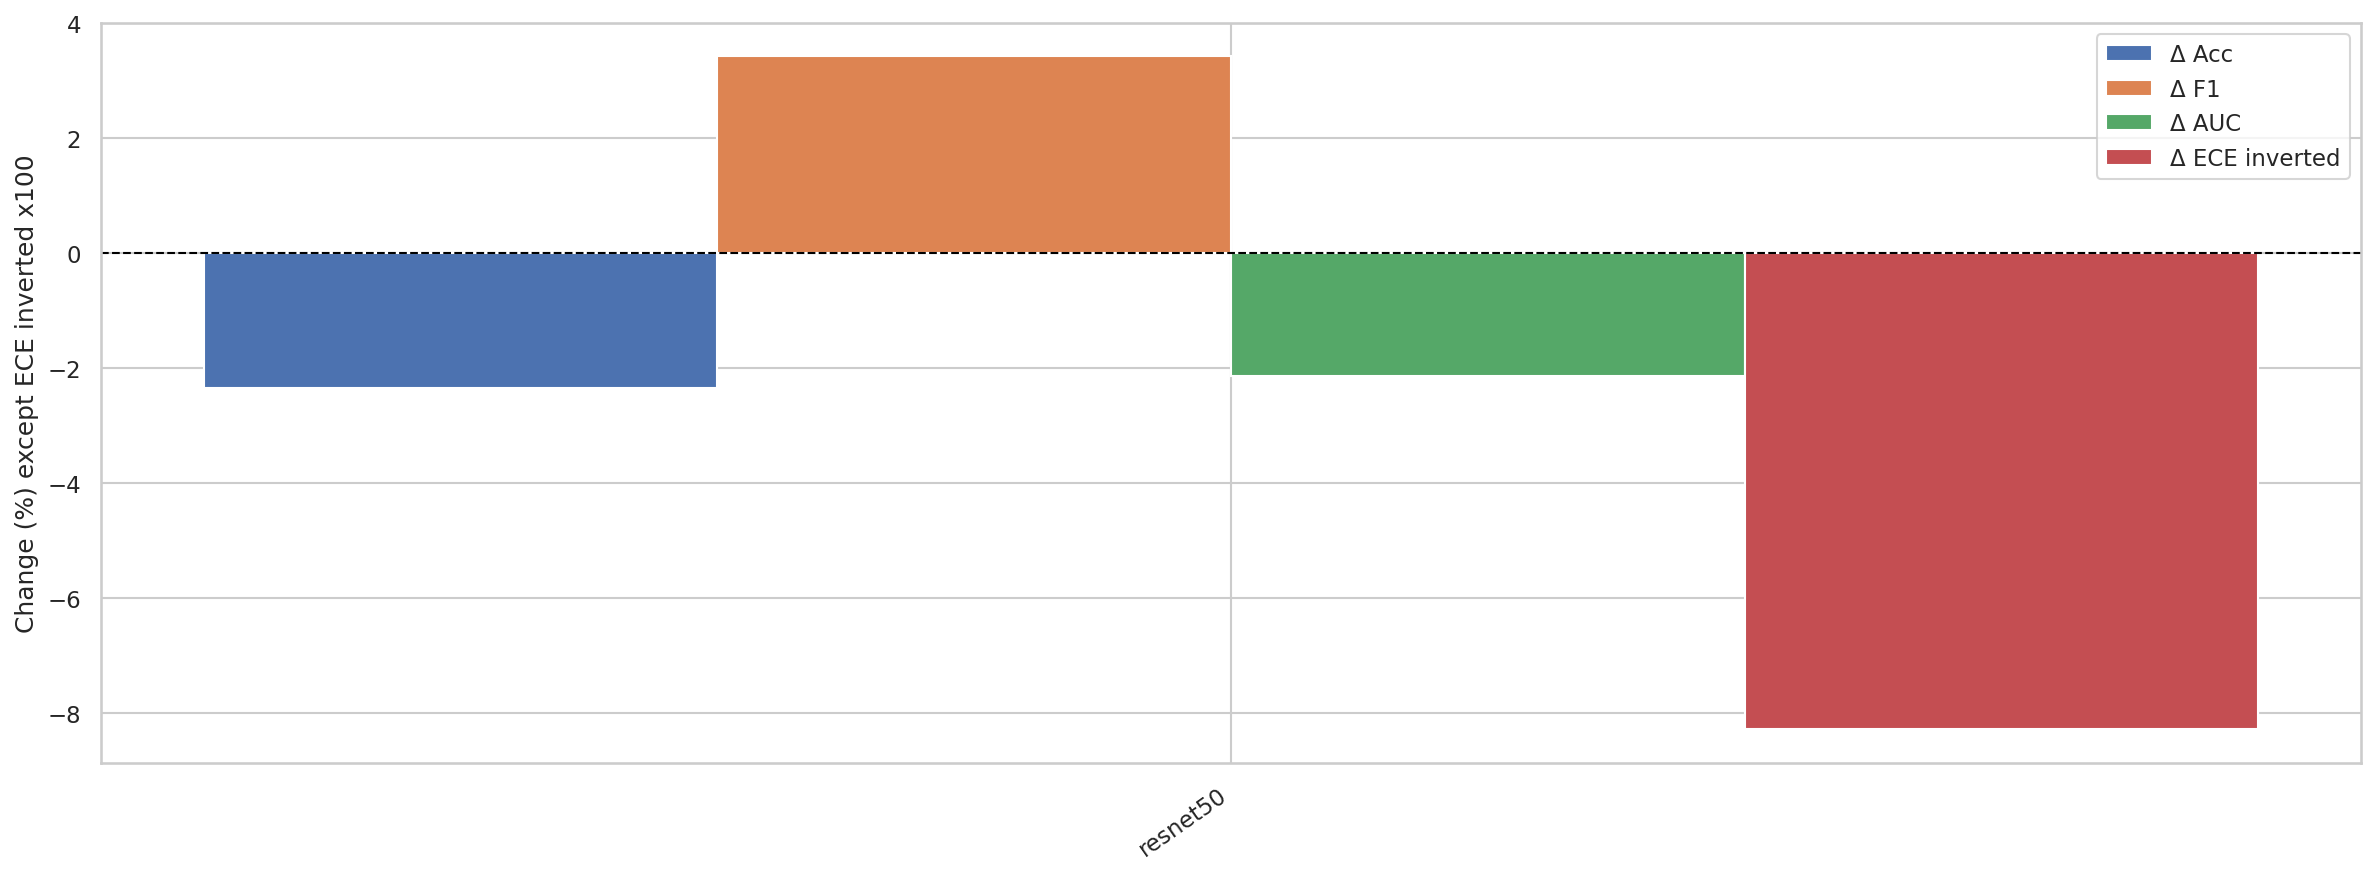

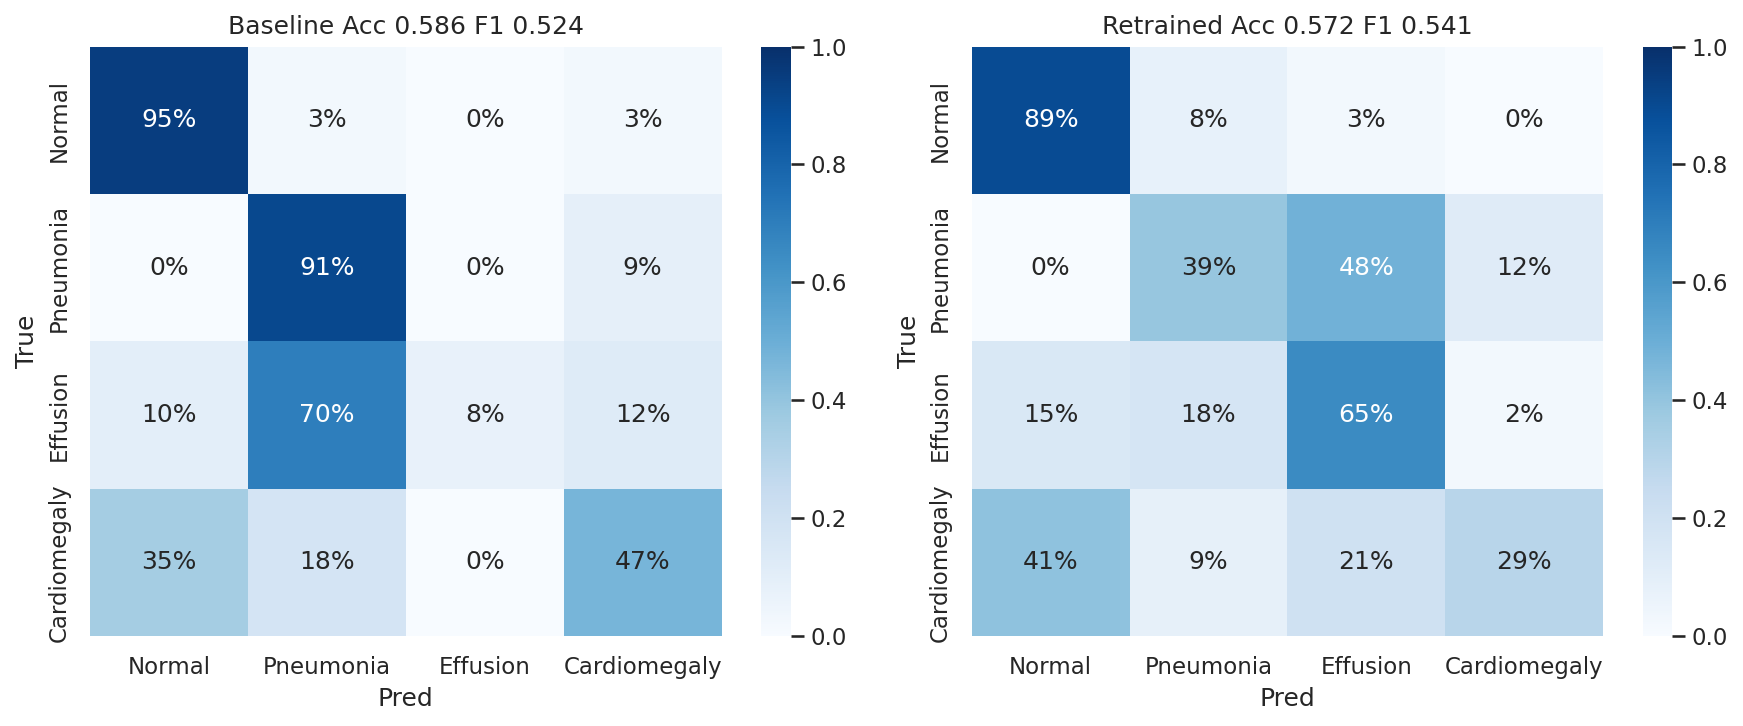

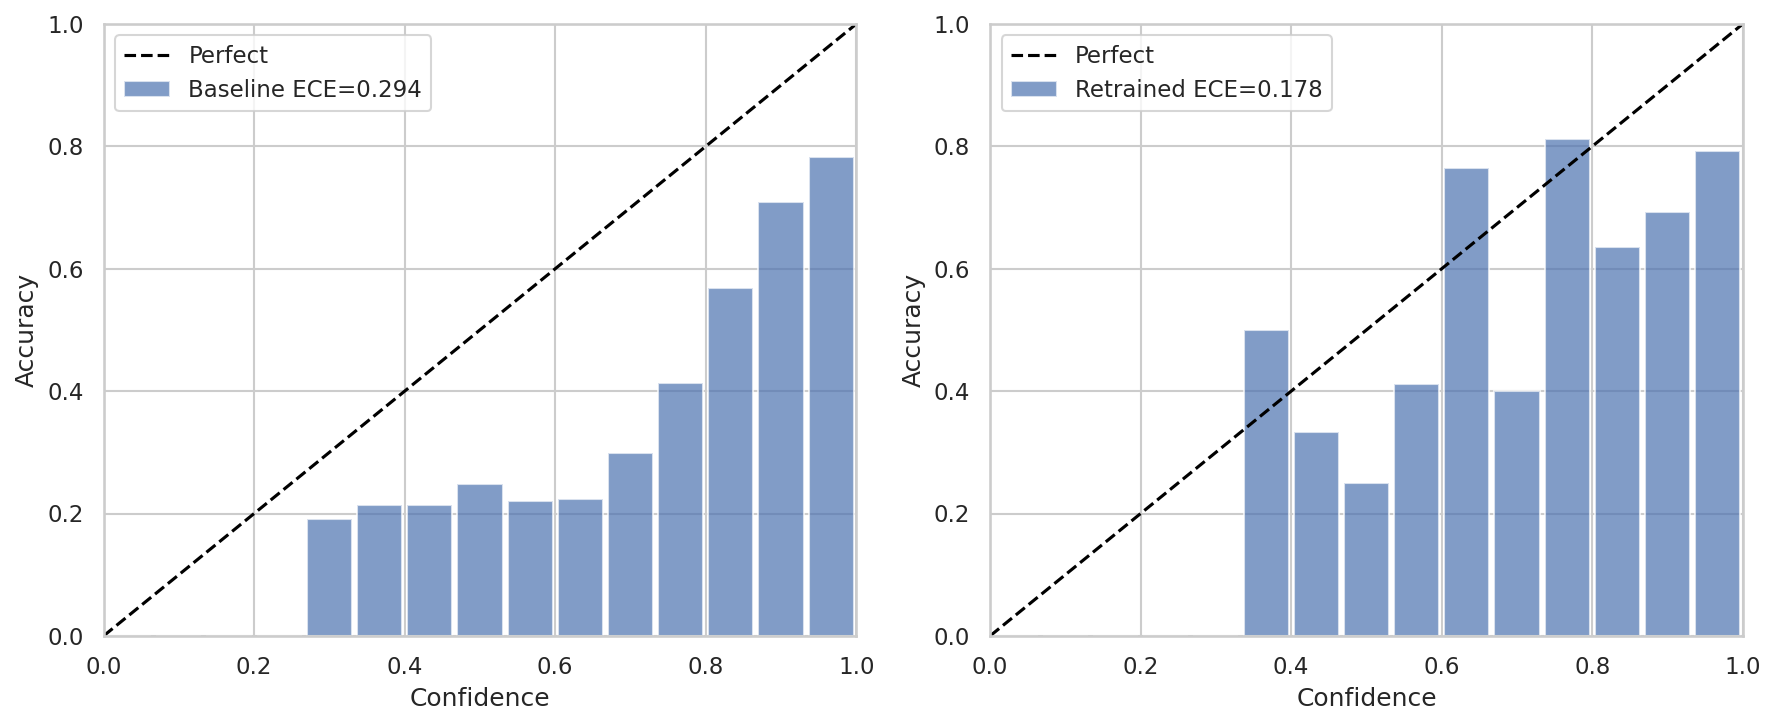

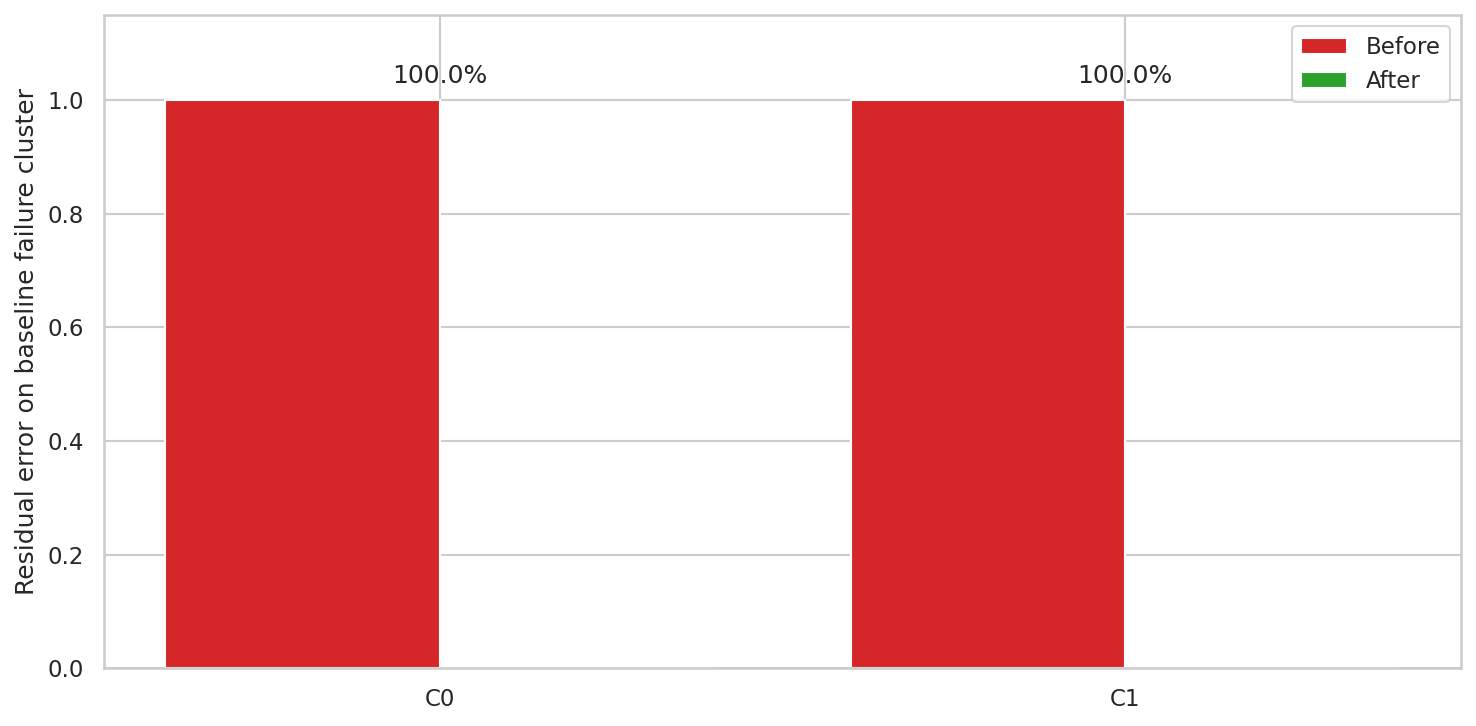

✓ Section 11 complete


In [14]:
def reliability_bins(probs, labels, n_bins=15):
    """Return per-bin confidence and accuracy for reliability diagrams."""
    conf = probs.max(axis=1)
    pred = probs.argmax(axis=1)
    acc = (pred == labels).astype(float)

    bins = np.linspace(0, 1, n_bins + 1)
    centers, bin_acc, bin_conf, counts = [], [], [], []

    for lo, hi in zip(bins[:-1], bins[1:]):
        mask = (conf > lo) & (conf <= hi)
        centers.append((lo + hi) / 2)
        counts.append(mask.sum())
        bin_acc.append(acc[mask].mean() if mask.any() else 0)
        bin_conf.append(conf[mask].mean() if mask.any() else 0)

    return np.array(centers), np.array(bin_acc), np.array(bin_conf), np.array(counts)


if len(improvement_df) > 0:
    best_model = improvement_df.sort_values('retrained_f1', ascending=False).iloc[0]['model']
else:
    best_model = baseline_df.sort_values('test_f1', ascending=False).iloc[0]['model']

print(f"Best model selected for detailed figures: {best_model}")


# Figure 1 — Baseline performance heatmap
fig1_df = baseline_df.set_index('model')[
    ['test_accuracy', 'test_f1', 'test_auc', 'test_ece']
].rename(
    columns={
        'test_accuracy': 'Accuracy',
        'test_f1': 'F1',
        'test_auc': 'AUC',
        'test_ece': 'ECE'
    }
)

plot_df = fig1_df.copy()
plot_df['ECE'] = 1 - plot_df['ECE']

plt.figure(figsize=(8, 6), dpi=150)
sns.heatmap(
    plot_df,
    annot=fig1_df,
    fmt='.3f',
    cmap='RdYlGn',
    cbar=True
)
plt.tight_layout()
plt.savefig(
    f"{CONFIG['figures_dir']}/fig1_baseline_heatmap.png",
    dpi=300,
    bbox_inches='tight'
)
plt.show()


# Figure 2 — Training curves
fig, axes = plt.subplots(2, 5, figsize=(22, 8), dpi=150)

for ax, model_name in zip(axes.ravel(), MODELS):
    hist = all_histories.get(model_name, {})

    if len(hist.get('val_loss', [])) == 0:
        ax.axis('off')
        continue

    epochs = np.arange(1, len(hist['val_loss']) + 1)

    ax.plot(epochs, hist['val_loss'], color='tab:blue')
    ax.set_ylabel('Val loss', color='tab:blue')
    ax.tick_params(axis='y', labelcolor='tab:blue')
    ax.set_xlabel('Epoch')
    ax.set_title(model_name, fontsize=10)

    ax2 = ax.twinx()
    ax2.plot(epochs, hist['val_f1'], color='tab:orange')
    ax2.set_ylabel('Val F1', color='tab:orange')
    ax2.tick_params(axis='y', labelcolor='tab:orange')

plt.tight_layout()
plt.savefig(
    f"{CONFIG['figures_dir']}/fig2_training_curves.png",
    dpi=300,
    bbox_inches='tight'
)
plt.show()


# Figure 3 — Baseline confusion matrices
fig, axes = plt.subplots(2, 5, figsize=(22, 9), dpi=150)

for ax, model_name in zip(axes.ravel(), MODELS):
    if model_name not in baseline_confusions:
        ax.axis('off')
        continue

    cm = baseline_confusions[model_name]
    cmn = np.divide(
        cm,
        cm.sum(axis=1, keepdims=True),
        out=np.zeros_like(cm, dtype=float),
        where=cm.sum(axis=1, keepdims=True) != 0
    )

    sns.heatmap(
        cmn,
        annot=True,
        fmt='.0%',
        cmap='Blues',
        xticklabels=CONFIG['class_names'],
        yticklabels=CONFIG['class_names'],
        ax=ax,
        cbar=False
    )
    ax.set_title(model_name, fontsize=10)
    ax.set_xlabel('Pred')
    ax.set_ylabel('True')

plt.tight_layout()
plt.savefig(
    f"{CONFIG['figures_dir']}/fig3_confusion_baseline.png",
    dpi=300,
    bbox_inches='tight'
)
plt.show()


# Figure 4 — Projection plots for best model
best_clustered = all_clustered[best_model]

fig, axes = plt.subplots(1, 2, figsize=(13, 5), dpi=150)

sc = axes[0].scatter(
    best_clustered['umap_x'],
    best_clustered['umap_y'],
    c=best_clustered['cluster'],
    cmap='tab10',
    s=16
)
axes[0].set_xlabel('Projection-1')
axes[0].set_ylabel('Projection-2')
fig.colorbar(sc, ax=axes[0])

for label_id, name in enumerate(CONFIG['class_names']):
    sub = best_clustered[best_clustered['true_label'] == label_id]
    axes[1].scatter(
        sub['umap_x'],
        sub['umap_y'],
        s=16,
        label=name
    )

axes[1].set_xlabel('Projection-1')
axes[1].set_ylabel('Projection-2')
axes[1].legend()

plt.tight_layout()
plt.savefig(
    f"{CONFIG['figures_dir']}/fig4_projection_best_model.png",
    dpi=300,
    bbox_inches='tight'
)
plt.show()


# Figure 5 — Projection plots for all models
fig, axes = plt.subplots(2, 5, figsize=(22, 9), dpi=150)

for ax, model_name in zip(axes.ravel(), MODELS):
    if model_name not in all_clustered:
        ax.axis('off')
        continue

    cdf = all_clustered[model_name]

    ax.scatter(
        cdf['umap_x'],
        cdf['umap_y'],
        c=cdf['cluster'],
        cmap='tab10',
        s=10
    )
    ax.set_title(model_name, fontsize=10)
    ax.set_xlabel('Projection-1')
    ax.set_ylabel('Projection-2')

plt.tight_layout()
plt.savefig(
    f"{CONFIG['figures_dir']}/fig5_projection_all_models.png",
    dpi=300,
    bbox_inches='tight'
)
plt.show()


# Figure 6 — Cluster profile radar chart
profile_df = all_profiles[best_model]

if len(profile_df) > 0:
    feats = [
        'brightness_mean',
        'contrast_mean',
        'sharpness_mean',
        'lesion_size_mean'
    ]

    radar = profile_df[['cluster'] + feats].copy()

    for feat in feats:
        mn, mx = radar[feat].min(), radar[feat].max()

        if pd.isna(mn) or pd.isna(mx) or mx == mn:
            radar[feat] = 0.5
        else:
            radar[feat] = (radar[feat] - mn) / (mx - mn)

    angles = np.linspace(0, 2 * np.pi, len(feats), endpoint=False).tolist()
    angles += angles[:1]

    fig = plt.figure(figsize=(7, 7), dpi=150)
    ax = fig.add_subplot(111, polar=True)

    for _, row in radar.iterrows():
        values = [row[f] for f in feats]
        values += values[:1]

        ax.plot(
            angles,
            values,
            label=f"Cluster {int(row['cluster'])}"
        )
        ax.fill(angles, values, alpha=0.08)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(['brightness', 'contrast', 'sharpness', 'lesion_size'])
    ax.set_ylim(0, 1)
    ax.legend(loc='upper right', bbox_to_anchor=(1.25, 1.1))

    plt.tight_layout()
    plt.savefig(
        f"{CONFIG['figures_dir']}/fig6_cluster_radar.png",
        dpi=300,
        bbox_inches='tight'
    )
    plt.show()
else:
    print(f"Skipping Figure 6: no cluster profile rows for {best_model}")


# Figure 7 — Improvement bar chart
if len(improvement_df) > 0:
    x = np.arange(len(improvement_df))
    width = 0.2

    fig, ax = plt.subplots(figsize=(16, 6), dpi=150)

    metrics = [
        ('delta_acc_pct', 'Δ Acc'),
        ('delta_f1_pct', 'Δ F1'),
        ('delta_auc_pct', 'Δ AUC'),
        ('delta_ece', 'Δ ECE inverted')
    ]

    for i, (col, label) in enumerate(metrics):
        vals = (
            -100 * improvement_df[col].values
            if col == 'delta_ece'
            else improvement_df[col].values
        )

        ax.bar(
            x + (i - 1.5) * width,
            vals,
            width,
            label=label
        )

    ax.axhline(0, color='black', linestyle='--', linewidth=1)
    ax.set_xticks(x)
    ax.set_xticklabels(improvement_df['model'], rotation=35, ha='right')
    ax.set_ylabel('Change (%) except ECE inverted x100')
    ax.legend()

    plt.tight_layout()
    plt.savefig(
        f"{CONFIG['figures_dir']}/fig7_improvement_bars.png",
        dpi=300,
        bbox_inches='tight'
    )
    plt.show()
else:
    print("Skipping Figure 7: improvement_df is empty")


# Figure 8 — Before vs after confusion matrices
if len(improvement_df) > 0 and best_model in retrained_confusions:
    fig, axes = plt.subplots(1, 2, figsize=(12, 5), dpi=150)

    base_row = baseline_df[baseline_df['model'] == best_model].iloc[0]
    ret_row = improvement_df[improvement_df['model'] == best_model].iloc[0]

    plot_items = [
        (
            axes[0],
            baseline_confusions[best_model],
            f"Baseline Acc {base_row['test_accuracy']:.3f} F1 {base_row['test_f1']:.3f}"
        ),
        (
            axes[1],
            retrained_confusions[best_model],
            f"Retrained Acc {ret_row['retrained_acc']:.3f} F1 {ret_row['retrained_f1']:.3f}"
        )
    ]

    for ax, cm, label in plot_items:
        cmn = np.divide(
            cm,
            cm.sum(axis=1, keepdims=True),
            out=np.zeros_like(cm, dtype=float),
            where=cm.sum(axis=1, keepdims=True) != 0
        )

        sns.heatmap(
            cmn,
            annot=True,
            fmt='.0%',
            cmap='Blues',
            xticklabels=CONFIG['class_names'],
            yticklabels=CONFIG['class_names'],
            ax=ax,
            vmin=0,
            vmax=1
        )

        ax.set_title(label)
        ax.set_xlabel('Pred')
        ax.set_ylabel('True')

    plt.tight_layout()
    plt.savefig(
        f"{CONFIG['figures_dir']}/fig8_confusion_comparison.png",
        dpi=300,
        bbox_inches='tight'
    )
    plt.show()
else:
    print("Skipping Figure 8: retrained results unavailable")


# Figure 9 — Reliability diagrams
if len(improvement_df) > 0 and best_model in retrained_predictions:
    base_pred = all_predictions[best_model]
    base_probs = np.stack(
        base_pred['prob_vector'].apply(lambda x: np.fromstring(x, sep=','))
    )
    base_labels = base_pred['true_label'].values

    ret_probs = retrained_predictions[best_model]['probs']
    ret_labels = retrained_predictions[best_model]['labels']

    fig, axes = plt.subplots(1, 2, figsize=(12, 5), dpi=150)

    plot_items = [
        (
            axes[0],
            base_probs,
            base_labels,
            f"Baseline ECE={compute_ece(base_probs, base_labels):.3f}"
        ),
        (
            axes[1],
            ret_probs,
            ret_labels,
            f"Retrained ECE={compute_ece(ret_probs, ret_labels):.3f}"
        )
    ]

    for ax, probs, labels, caption in plot_items:
        centers, bacc, bconf, counts = reliability_bins(
            probs,
            labels,
            CONFIG['ece_bins']
        )

        ax.bar(
            centers,
            bacc,
            width=1 / CONFIG['ece_bins'] * 0.9,
            alpha=0.7,
            label=caption
        )

        ax.plot(
            [0, 1],
            [0, 1],
            linestyle='--',
            color='black',
            label='Perfect'
        )

        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        ax.set_xlabel('Confidence')
        ax.set_ylabel('Accuracy')
        ax.legend()

    plt.tight_layout()
    plt.savefig(
        f"{CONFIG['figures_dir']}/fig9_ece_reliability.png",
        dpi=300,
        bbox_inches='tight'
    )
    plt.show()
else:
    print("Skipping Figure 9: retrained probability outputs unavailable")


# Figure 10 — Cluster residual error reduction
if len(improvement_df) > 0 and best_model in retrained_predictions:
    clustered = all_clustered[best_model]

    ret_df = pd.DataFrame({
        'image_path': retrained_predictions[best_model]['paths'],
        'true_label': retrained_predictions[best_model]['labels'],
        'pred_label': retrained_predictions[best_model]['preds'],
    })

    cluster_map = clustered[['image_path', 'cluster']].drop_duplicates()
    ret_clustered = ret_df.merge(cluster_map, on='image_path', how='inner')

    before_rates, after_rates = [], []
    clusters = sorted(clustered['cluster'].unique())

    for c in clusters:
        before_rates.append(1.0)

        sub = ret_clustered[ret_clustered['cluster'] == c]

        after_rates.append(
            float((sub['true_label'] != sub['pred_label']).mean())
            if len(sub)
            else 0
        )

    x = np.arange(len(clusters))

    fig, ax = plt.subplots(figsize=(10, 5), dpi=150)

    ax.bar(
        x - 0.2,
        before_rates,
        0.4,
        color='tab:red',
        label='Before'
    )

    ax.bar(
        x + 0.2,
        after_rates,
        0.4,
        color='tab:green',
        label='After'
    )

    for i, (b, a) in enumerate(zip(before_rates, after_rates)):
        ax.text(
            i,
            max(b, a) + 0.03,
            f"{(b - a) * 100:.1f}%",
            ha='center'
        )

    ax.set_xticks(x)
    ax.set_xticklabels([f"C{c}" for c in clusters])
    ax.set_ylabel('Residual error on baseline failure cluster')
    ax.set_ylim(0, 1.15)
    ax.legend()

    plt.tight_layout()
    plt.savefig(
        f"{CONFIG['figures_dir']}/fig10_cluster_error_reduction.png",
        dpi=300,
        bbox_inches='tight'
    )
    plt.show()
else:
    print("Skipping Figure 10: retrained predictions unavailable")

print("✓ Section 11 complete")

In [15]:
def pretty_model_name(name: str) -> str:
    """Convert internal model id to display name."""
    return {
        'resnet50': 'ResNet-50',
        'resnet101': 'ResNet-101',
        'densenet121': 'DenseNet-121',
        'efficientnet_b3': 'EfficientNet-B3',
        'efficientnet_b5': 'EfficientNet-B5',
        'mobilenetv3_large_100': 'MobileNetV3-Large',
        'vit_base_patch16_224': 'ViT-B/16',
        'swin_tiny_patch4_window7_224': 'Swin-Tiny',
        'convnext_small': 'ConvNeXt-Small',
        'maxvit_tiny_tf_224': 'MaxViT-Tiny'
    }.get(name, name)


summary_lines = []

if len(improvement_df) > 0:
    header = (
        "| Model | Family | Acc (base->ret) | F1 (base->ret) | "
        "AUC (base->ret) | ECE (base->ret) | Delta Acc % | Strategy |"
    )
    sep = "|---|---|---:|---:|---:|---:|---:|---|"

    summary_lines.extend([header, sep])

    for _, row in improvement_df.iterrows():
        summary_lines.append(
            f"| {pretty_model_name(row['model'])} | {row['family'].upper()} | "
            f"{row['baseline_acc']:.3f}->{row['retrained_acc']:.3f} | "
            f"{row['baseline_f1']:.3f}->{row['retrained_f1']:.3f} | "
            f"{row['baseline_auc']:.3f}->{row['retrained_auc']:.3f} | "
            f"{row['baseline_ece']:.3f}->{row['retrained_ece']:.3f} | "
            f"{row['delta_acc_pct']:+.1f}% | {row['strategy'].title()} |"
        )
else:
    summary_lines.append(
        "Retraining results are unavailable because `improvement_df` is empty."
    )


best_baseline = None
if len(baseline_df) > 0:
    best_baseline = baseline_df.sort_values(
        'test_f1',
        ascending=False
    ).iloc[0]


most_improved = None
if len(improvement_df) > 0:
    most_improved = improvement_df.sort_values(
        'delta_f1_pct',
        ascending=False
    ).iloc[0]


all_failure_pairs = []

for df in all_failures.values():
    if len(df) == 0:
        continue

    all_failure_pairs.extend(
        list(zip(df['true_label'], df['pred_label']))
    )


if all_failure_pairs:
    dominant = Counter(all_failure_pairs).most_common(1)[0][0]
    dominant_text = (
        f"{CONFIG['class_names'][dominant[0]]} misclassified as "
        f"{CONFIG['class_names'][dominant[1]]}"
    )
else:
    dominant_text = "No dominant failure pattern detected"


clinical_recommendation = (
    "Use the retrained best-F1 model only as a triage/decision-support system, "
    "not as an autonomous diagnostic device. Deploy with calibration monitoring, "
    "subgroup/failure-cluster audits, radiologist override, and prospective "
    "validation on local hospital data before clinical use."
)


final_text = "\n".join(summary_lines) + "\n\n"

if best_baseline is not None:
    final_text += (
        f"- Best performing baseline model: "
        f"{pretty_model_name(best_baseline['model'])} "
        f"(F1={best_baseline['test_f1']:.3f}, "
        f"AUC={best_baseline['test_auc']:.3f})\n"
    )
else:
    final_text += "- Best performing baseline model: unavailable\n"


if most_improved is not None:
    final_text += (
        f"- Most improved model after retraining: "
        f"{pretty_model_name(most_improved['model'])} "
        f"(Delta F1={most_improved['delta_f1_pct']:+.1f}%)\n"
    )
else:
    final_text += "- Most improved model after retraining: unavailable\n"


final_text += f"- Dataset: CheXpert-v1.0-small 4-class simplified experiment\n"
final_text += f"- Dataset-level dominant failure pattern: {dominant_text}\n"
final_text += f"- Recommendation for clinical deployment: {clinical_recommendation}\n"


print(final_text)

summary_path = Path(CONFIG['results_dir']) / 'FINAL_SUMMARY_CheXpert.md'
summary_path.write_text(final_text)

print(f"Saved final summary to: {summary_path}")
print("✓ Section 12 complete")

| Model | Family | Acc (base->ret) | F1 (base->ret) | AUC (base->ret) | ECE (base->ret) | Delta Acc % | Strategy |
|---|---|---:|---:|---:|---:|---:|---|
| ResNet-50 | CNN | 0.586->0.572 | 0.524->0.541 | 0.862->0.844 | 0.095->0.178 | -2.4% | Selective |

- Best performing baseline model: ResNet-50 (F1=0.524, AUC=0.862)
- Most improved model after retraining: ResNet-50 (Delta F1=+3.4%)
- Dataset: CheXpert-v1.0-small 4-class simplified experiment
- Dataset-level dominant failure pattern: Effusion misclassified as Pneumonia
- Recommendation for clinical deployment: Use the retrained best-F1 model only as a triage/decision-support system, not as an autonomous diagnostic device. Deploy with calibration monitoring, subgroup/failure-cluster audits, radiologist override, and prospective validation on local hospital data before clinical use.

Saved final summary to: /kaggle/working/results/FINAL_SUMMARY_CheXpert.md
✓ Section 12 complete


In [16]:
# =====================================
# Section 13: Save Cross-Notebook Compatible Results — CheXpert
# Aligned with unified pipeline (shared with APTOS, MedMNIST, ISIC, Kvasir, BUSI, etc.)
# =====================================
DATASET_NAME = 'chexpert'
DATASET_DISPLAY = 'CheXpert-v1.0-small (Chest X-ray, 4-class)'

print(f"Saving cross-notebook results for {DATASET_DISPLAY}...")

Path(CONFIG['results_dir']).mkdir(parents=True, exist_ok=True)

# ── 1. Improvement Results (Failure-Aware Retraining vs Baseline) ──────
if 'improvement_df' in globals() and isinstance(improvement_df, pd.DataFrame):
    improvement_df_export = improvement_df.copy()
    improvement_df_export['dataset'] = DATASET_NAME
    out_path = f'{CONFIG["results_dir"]}/improvement_{DATASET_NAME}.csv'
    improvement_df_export.to_csv(out_path, index=False)
    print(f"  Saved improvement results: {len(improvement_df_export)} models → {out_path}")
else:
    print("  improvement_df not found or empty — skipping improvement export")

# ── 2. Untargeted Control Results (Compute-Matched Retraining) ─────────
if 'untargeted_df' in globals() and isinstance(untargeted_df, pd.DataFrame):
    untargeted_df_export = untargeted_df.copy()
    untargeted_df_export['dataset'] = DATASET_NAME
    out_path = f'{CONFIG["results_dir"]}/untargeted_control_{DATASET_NAME}.csv'
    untargeted_df_export.to_csv(out_path, index=False)
    print(f"  Saved untargeted control: {len(untargeted_df_export)} models → {out_path}")
else:
    print("  untargeted_df not found or empty — skipping untargeted control export")

# ── 3. Cluster Summary (Failure Clustering Metadata) ────────────────────
cluster_rows = []
has_cluster_data = False

if 'cluster_summaries' in globals() and isinstance(cluster_summaries, dict):
    for model_name, summary in cluster_summaries.items():
        n_failures = len(all_failures[model_name]) if (model_name in all_failures) else 0
        cluster_rows.append({
            'model': model_name,
            'dataset': DATASET_NAME,
            'best_k': summary.get('best_k', 2),
            'best_k_bic': summary.get('best_k_bic', 2),
            'silhouette': summary.get('silhouette', float('nan')),
            'mean_ari': summary.get('mean_ari', float('nan')),
            'n_failures': n_failures,
        })
    has_cluster_data = len(cluster_rows) > 0

if has_cluster_data:
    cluster_summary_df = pd.DataFrame(cluster_rows)
    out_path = f'{CONFIG["results_dir"]}/cluster_summary_{DATASET_NAME}.csv'
    cluster_summary_df.to_csv(out_path, index=False)
    print(f"  Saved cluster summaries: {len(cluster_summary_df)} models → {out_path}")
else:
    print("  No clustering summaries available — skipping cluster export")

# ── 4. Temperature Scaling Results (Calibration) ────────────────────────
# Note: only exported if temperature scaling columns were added to baseline_df upstream
if 'baseline_df' in globals() and isinstance(baseline_df, pd.DataFrame):
    temp_cols = ['model', 'temperature', 'test_ece', 'test_ece_temp_scaled']
    if all(c in baseline_df.columns for c in temp_cols):
        temp_export = baseline_df[temp_cols].copy()
        temp_export['dataset'] = DATASET_NAME
        out_path = f'{CONFIG["results_dir"]}/temperature_scaling_{DATASET_NAME}.csv'
        temp_export.to_csv(out_path, index=False)
        print(f"  Saved temperature scaling: {len(temp_export)} models → {out_path}")
    else:
        missing_cols = [c for c in temp_cols if c not in baseline_df.columns]
        print(f"  Missing temp scaling columns: {missing_cols} — skipping export")
else:
    print("  baseline_df not available — skipping temperature scaling export")

# ── Final Summary Message ───────────────────────────────────────────────
print(f"\nAll cross-notebook result files saved for dataset='{DATASET_NAME}'")
print(f"   Files written to: {CONFIG['results_dir']}")
print(f"   Dataset: {DATASET_DISPLAY}")
print(f"   Results ready for Section 13: Cross-Dataset Comparison.")


Saving cross-notebook results for CheXpert-v1.0-small (Chest X-ray, 4-class)...
  Saved improvement results: 1 models → /kaggle/working/results/improvement_chexpert.csv
  Saved untargeted control: 1 models → /kaggle/working/results/untargeted_control_chexpert.csv
  Saved cluster summaries: 1 models → /kaggle/working/results/cluster_summary_chexpert.csv
  Missing temp scaling columns: ['temperature', 'test_ece_temp_scaled'] — skipping export

All cross-notebook result files saved for dataset='chexpert'
   Files written to: /kaggle/working/results
   Dataset: CheXpert-v1.0-small (Chest X-ray, 4-class)
   Results ready for Section 13: Cross-Dataset Comparison.
